# Paired biopsy–resection phosphoproteomics analysis


This notebook analyzes DIA-NN phosphosite-level intensities for paired biopsy
and resection samples from non-tumor liver and HCC. Phosphosites are represented
as `gene_residue-position` identifiers. The workflow covers sample matching,
phosphosite/protein identification QC, log2 transformation, missingness filtering,
within-condition KNN imputation, paired testing, a non-imputed paired limma
sensitivity analysis, PCA, patient-blocked permutation testing, and PTMsigDB-ready export.

**Primary inputs**

- `diann_phospho_report.phosphosites_90_v2.tsv`: DIA-NN phosphosite report.
- `../sample_mapping_BvR.csv`: patient/sample mapping and clinical covariates.

**Key retained decisions**

- Only HCC cases with all four phosphoproteomics samples are eligible.
- Patients with insufficient phosphosite identifications are excluded later in
  the workflow; the stored notebook note lists D, E, I, L, N, O, Q, and T as the
  retained proteomics-overlap patients and notes that U is missing.
- Zeros are converted to missing values before log2 transformation.
- Three-neighbor KNN imputation is performed separately by sampling condition.


## 1. Environment and imports

Load data-processing, plotting, phosphosite, imputation, PCA, and limma dependencies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pprint import pprint
from scipy import stats
from functools import reduce
#import dash_bio
import pyarrow

import seaborn as sns
import math
from scipy.stats import linregress
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import pdist
from scipy.stats import percentileofscore

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer

from patsy import dmatrix, Treatment
from inmoose.limma import lmFit, eBayes, topTable

import itertools

from importlib.metadata import version

from patsy import dmatrix, Treatment


from inmoose.limma import lmFit, eBayes, topTable

import csv
#import plotly.express as px

#import dash_bio

# PCA that can handle missing values
#from pyppca import ppca

# save as pdf
#import kaleido
import os

from datetime import datetime
today = datetime.today().strftime('%Y-%m-%d')

from tqdm import tqdm

%matplotlib inline
pd.set_option('display.max_columns', None)

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

sns.set(font_scale=1.5)
sns.set_style("ticks")

## 2. Load and prepare phosphosite intensities

Read the DIA-NN phosphosite table, remove entries without gene names, create site identifiers, standardize run names, replace zeros with missing values, and log2-transform.

In [2]:
# Change the file name below to your input file name
input_file_name = 'diann_phospho_report.phosphosites_90_v2.tsv'

In [3]:
df = pd.read_csv(input_file_name, sep='\t')
df.columns

Index(['Protein', 'Protein.Names', 'Gene.Names', 'Residue', 'Site', 'Sequence',
       '/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/016_BR-LF-3P_PO4_C21.raw.dia',
       '/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/061_BR-LF-3P_PO4_C21.raw.dia',
       '/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/057_BR-LF-3P_PO4_C21.raw.dia',
       '/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/002_BR-LF-3P_PO4_C21.raw.dia',
       '/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/037_BR-LF-3P_PO4_C21.raw.dia',
       '/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/090_BR-LF-3P_PO4_C21.raw.dia',
       '/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/066_BR-LF-3P_PO4_C21.raw.dia',
       '/scicore/home/heimm/GROUP/Fredrik/pro

In [4]:
df[~df['Protein.Names'].str.endswith('HUMAN')]

,Protein,Protein.Names,Gene.Names,Residue,Site,Sequence,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/016_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/061_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/057_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/002_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/037_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/090_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/066_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/025_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/068r_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/055_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/054_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/068_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/006_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/013_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/028_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/038_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/046_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/033_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/023_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/074_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/078_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/026_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/053_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/029_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/081_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/007_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/071_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/076_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/071r_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/049_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/050_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/051_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/069_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/012_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredri

In [5]:
df.tail()

,Protein,Protein.Names,Gene.Names,Residue,Site,Sequence,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/016_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/061_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/057_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/002_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/037_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/090_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/066_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/025_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/068r_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/055_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/054_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/068_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/006_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/013_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/028_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/038_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/046_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/033_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/023_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/074_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/078_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/026_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/053_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/029_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/081_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/007_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/071_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/076_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/071r_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/049_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/050_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/051_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/069_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/012_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredri

In [6]:
df = df[~df['Gene.Names'].isna()]

In [7]:
df['site_id'] = df['Gene.Names'].str.cat(df['Residue'].str.cat(df['Site'].astype(str)), sep='_')
df.head()

,Protein,Protein.Names,Gene.Names,Residue,Site,Sequence,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/016_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/061_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/057_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/002_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/037_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/090_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/066_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/025_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/068r_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/055_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/054_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/068_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/006_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/013_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/028_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/038_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/046_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/033_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/023_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/074_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/078_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/026_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/053_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/029_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/081_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/007_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/071_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/076_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/071r_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/049_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/050_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/051_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/069_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/012_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredri

In [8]:
df.isna().sum()

Protein                                                                                                               0
Protein.Names                                                                                                         0
Gene.Names                                                                                                            0
Residue                                                                                                               0
Site                                                                                                                  0
                                                                                                                     ..
/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/011_BR-LF-3P_PO4_C21.raw.dia    0
/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/087_BR-LF-3P_PO4_C21.raw.dia    0
/scicore/home/heimm/GROUP/Fredrik/projec

In [9]:
df_ = df.copy()
df_.index = df_.site_id

In [10]:
df_ = df_.drop(['Protein', 'Protein.Names', 'Gene.Names', 'Residue', 'Site', 'Sequence', 'site_id'], axis=1)
df_.head()

,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/016_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/061_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/057_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/002_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/037_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/090_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/066_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/025_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/068r_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/055_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/054_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/068_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/006_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/013_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/028_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/038_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/046_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/033_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/023_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/074_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/078_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/026_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/053_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/029_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/081_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/007_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/071_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/076_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/071r_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/049_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/050_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/051_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/069_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/012_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/0

In [11]:
df_.columns = df_.columns.str.split('/').str[-1].str.split('.').str[0]
df_.head()

,016_BR-LF-3P_PO4_C21,061_BR-LF-3P_PO4_C21,057_BR-LF-3P_PO4_C21,002_BR-LF-3P_PO4_C21,037_BR-LF-3P_PO4_C21,090_BR-LF-3P_PO4_C21,066_BR-LF-3P_PO4_C21,025_BR-LF-3P_PO4_C21,068r_BR-LF-3P_PO4_C21,055_BR-LF-3P_PO4_C21,054_BR-LF-3P_PO4_C21,068_BR-LF-3P_PO4_C21,006_BR-LF-3P_PO4_C21,013_BR-LF-3P_PO4_C21,028_BR-LF-3P_PO4_C21,038_BR-LF-3P_PO4_C21,046_BR-LF-3P_PO4_C21,033_BR-LF-3P_PO4_C21,023_BR-LF-3P_PO4_C21,074_BR-LF-3P_PO4_C21,078_BR-LF-3P_PO4_C21,026_BR-LF-3P_PO4_C21,053_BR-LF-3P_PO4_C21,029_BR-LF-3P_PO4_C21,081_BR-LF-3P_PO4_C21,007_BR-LF-3P_PO4_C21,071_BR-LF-3P_PO4_C21,076_BR-LF-3P_PO4_C21,071r_BR-LF-3P_PO4_C21,049_BR-LF-3P_PO4_C21,050_BR-LF-3P_PO4_C21,051_BR-LF-3P_PO4_C21,069_BR-LF-3P_PO4_C21,012_BR-LF-3P_PO4_C21,015_BR-LF-3P_PO4_C21,027_BR-LF-3P_PO4_C21,019_BR-LF-3P_PO4_C21,032_BR-LF-3P_PO4_C21,084_BR-LF-3P_PO4_C21,072_BR-LF-3P_PO4_C21,075_BR-LF-3P_PO4_C21,004_BR-LF-3P_PO4_C21,014_BR-LF-3P_PO4_C21,077_BR-LF-3P_PO4_C21,072r_BR-LF-3P_PO4_C21,024_BR-LF-3P_PO4_C21,042_BR-LF-3P_PO4_C21,048_BR-LF-3P_PO4_C21,069r_BR-LF-3P_PO4_C21,018_BR-LF-3P_PO4_C21,031_BR-LF-3P_PO4_C21,085_BR-LF-3P_PO4_C21,035_BR-LF-3P_PO4_C21,052_BR-LF-3P_PO4_C21,059_BR-LF-3P_PO4_C21,030_BR-LF-3P_PO4_C21,056_BR-LF-3P_PO4_C21,073r_BR-LF-3P_PO4_C21,047_BR-LF-3P_PO4_C21,088_BR-LF-3P_PO4_C21,086_BR-LF-3P_PO4_C21,058_BR-LF-3P_PO4_C21,001_BR-LF-3P_PO4_C21,041_BR-LF-3P_PO4_C21,034_BR-LF-3P_PO4_C21,089_BR-LF-3P_PO4_C21,022_BR-LF-3P_PO4_C21,020_BR-LF-3P_PO4_C21,080_BR-LF-3P_PO4_C21,063_BR-LF-3P_PO4_C21,021_BR-LF-3P_PO4_C21,011_BR-LF-3P_PO4_C21,087_BR-LF-3P_PO4_C21,045_BR-LF-3P_PO4_C21,005_BR-LF-3P_PO4_C21
site_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
RAMACL_S36,0.0,0.0,355018.0,0.0,485485.00,0.0,124118.0,0.0,0.0,402911.0,26211.1,0,0.0,53864.8,0.0,44911.2,77258.6,0.0,0.0,0.0,94790.4,0.0,76872.6,0.0,346548.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,430350.0,0,286524.0,0.0,0.0,284141.0,0.0,0.0,0.0,61574.1,0.0,0.0,0.0,399881.0,0.0,45891.3,0.0,122542.0,0.0,0.0,201487.0,94138.2,0.0,0.0,0.0,263776.0,135329.0,400033.0,0.0,0.0,880179.0,0.0,0.0,0.0,504232.0,89180.9,0.0
SLC12A8_S665,0.0,0.0,0.0,0.0,245431.00,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
E2F8_T58,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,216195.0,0.0,0.0
E2F8_S71,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,118510.0,0.0,0.0,85020.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,78277.7,0.0,0.0,40815.2,0.0,0.0,0.0,297946.0,0.0,0.0
ESYT2_S678,0.0,0.0,0.0,0.0,7953.56,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
df_ = df_.replace(0, np.nan)
df_.head()

,016_BR-LF-3P_PO4_C21,061_BR-LF-3P_PO4_C21,057_BR-LF-3P_PO4_C21,002_BR-LF-3P_PO4_C21,037_BR-LF-3P_PO4_C21,090_BR-LF-3P_PO4_C21,066_BR-LF-3P_PO4_C21,025_BR-LF-3P_PO4_C21,068r_BR-LF-3P_PO4_C21,055_BR-LF-3P_PO4_C21,054_BR-LF-3P_PO4_C21,068_BR-LF-3P_PO4_C21,006_BR-LF-3P_PO4_C21,013_BR-LF-3P_PO4_C21,028_BR-LF-3P_PO4_C21,038_BR-LF-3P_PO4_C21,046_BR-LF-3P_PO4_C21,033_BR-LF-3P_PO4_C21,023_BR-LF-3P_PO4_C21,074_BR-LF-3P_PO4_C21,078_BR-LF-3P_PO4_C21,026_BR-LF-3P_PO4_C21,053_BR-LF-3P_PO4_C21,029_BR-LF-3P_PO4_C21,081_BR-LF-3P_PO4_C21,007_BR-LF-3P_PO4_C21,071_BR-LF-3P_PO4_C21,076_BR-LF-3P_PO4_C21,071r_BR-LF-3P_PO4_C21,049_BR-LF-3P_PO4_C21,050_BR-LF-3P_PO4_C21,051_BR-LF-3P_PO4_C21,069_BR-LF-3P_PO4_C21,012_BR-LF-3P_PO4_C21,015_BR-LF-3P_PO4_C21,027_BR-LF-3P_PO4_C21,019_BR-LF-3P_PO4_C21,032_BR-LF-3P_PO4_C21,084_BR-LF-3P_PO4_C21,072_BR-LF-3P_PO4_C21,075_BR-LF-3P_PO4_C21,004_BR-LF-3P_PO4_C21,014_BR-LF-3P_PO4_C21,077_BR-LF-3P_PO4_C21,072r_BR-LF-3P_PO4_C21,024_BR-LF-3P_PO4_C21,042_BR-LF-3P_PO4_C21,048_BR-LF-3P_PO4_C21,069r_BR-LF-3P_PO4_C21,018_BR-LF-3P_PO4_C21,031_BR-LF-3P_PO4_C21,085_BR-LF-3P_PO4_C21,035_BR-LF-3P_PO4_C21,052_BR-LF-3P_PO4_C21,059_BR-LF-3P_PO4_C21,030_BR-LF-3P_PO4_C21,056_BR-LF-3P_PO4_C21,073r_BR-LF-3P_PO4_C21,047_BR-LF-3P_PO4_C21,088_BR-LF-3P_PO4_C21,086_BR-LF-3P_PO4_C21,058_BR-LF-3P_PO4_C21,001_BR-LF-3P_PO4_C21,041_BR-LF-3P_PO4_C21,034_BR-LF-3P_PO4_C21,089_BR-LF-3P_PO4_C21,022_BR-LF-3P_PO4_C21,020_BR-LF-3P_PO4_C21,080_BR-LF-3P_PO4_C21,063_BR-LF-3P_PO4_C21,021_BR-LF-3P_PO4_C21,011_BR-LF-3P_PO4_C21,087_BR-LF-3P_PO4_C21,045_BR-LF-3P_PO4_C21,005_BR-LF-3P_PO4_C21
site_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
RAMACL_S36,NaN,NaN,355018.0,NaN,485485.00,NaN,124118.0,NaN,NaN,402911.0,26211.1,NaN,NaN,53864.8,NaN,44911.2,77258.6,NaN,NaN,NaN,94790.4,NaN,76872.6,NaN,346548.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,430350.0,NaN,286524.0,NaN,NaN,284141.0,NaN,NaN,NaN,61574.1,NaN,NaN,NaN,399881.0,NaN,45891.3,NaN,122542.0,NaN,NaN,201487.0,94138.2,NaN,NaN,NaN,263776.0,135329.0,400033.0,NaN,NaN,880179.0,NaN,NaN,NaN,504232.0,89180.9,NaN
SLC12A8_S665,NaN,NaN,NaN,NaN,245431.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E2F8_T58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,216195.0,NaN,NaN
E2F8_S71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,118510.0,NaN,NaN,85020.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78277.7,NaN,NaN,40815.2,NaN,NaN,NaN,297946.0,NaN,NaN
ESYT2_S678,NaN,NaN,NaN,NaN,7953.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df_log = np.log2(df_)

In [14]:
df_log.index.str.contains(';').sum()

np.int64(0)

In [15]:
df_log.index.isna().sum()

np.int64(0)

In [16]:
df_log.shape

(9279, 75)

## 3. Select and verify mapped samples

Load complete HCC phosphoproteomics pairs, report missing/extra runs, and restrict the intensity matrix to mapped samples.

In [17]:
# New sample mapping with clinical features
meta = pd.read_csv('../sample_mapping_BvR.csv')
# We only do HCC
meta = meta[meta['Tumor diagnosis'] == 'HCC']
# Only take patients were we have all transcriptome samples
phos_cols = ['Biopsy_nt_phospho', 'Biopsy_tu_phospho',
             'Resection_nt_phospho', 'Resection_tu_phospho']
meta = meta.dropna(subset=phos_cols)

meta.head()

,Patient ID,Biopsy_nt_transcriptome,Biopsy_tu_transcriptome,Resection_nt_transcriptome,Resection_tu_transcriptome,Biopsy_nt_proteome,Biopsy_tu_proteome,Resection_nt_protome,Resection_tu_protome,Biopsy_nt_phospho,Biopsy_tu_phospho,Resection_nt_phospho,Resection_tu_phospho,Age,Sex,PreBx_MELD,PreBx_ALAT,PreBx_ASAT,PreBx_GGT,PreBx_AP,PreBx_Albumin,PreBx_Bilirubin,PreBx_Quick,PreBx_Hb,PreBx_Lc,PreBx_Tc,PreBx_CRP,PreBx_AFP,PreOP_MELD,PreOP_ALAT,PreOP_ASAT,PreOP_GGT,PreOP_AP,PreOP_Albumin,PreOP_Bilirubin,PreOP_Quick,PreOP_Hb,PreOP_Lc,PreOP_Tc,PreOP_CRP,PreOP_AFP,CHILD,BCLC,Nr of nodules,Max nodule size,Time between resection and biopsy,Total surgery time = ischemia time,Tumor diagnosis,Biopsy_nt_hepatocyte,Resection_nt_hepatocyte,Biopsy_nt_stroma,Resection_nt_stroma,Biopsy_tu_tumor,Resection_tu_tumor,Biopsy_tu_stroma,Resection_tu_stroma,Biopsy_tu_necrosis,Resection_tu_necrosis,Biopsy_tu_nontumor,Resection_tu_nontumor
5,C,BSSE_QGF_145480,BSSE_QGF_145481,BSSE_QGF_182091,BSSE_QGF_182092,001_BR-LF-3_C21,002_BR-LF-3_C21,041_BR-LF-3_C21,042rr_BR-LF-3_C21,001_BR-LF-3P_PO4_C21,002_BR-LF-3P_PO4_C21,041_BR-LF-3P_PO4_C21,042_BR-LF-3P_PO4_C21,83.0,M,6.0,48.0,48.0,467.0,129.0,37.0,12.0,93.0,122.0,4.0,149.0,3.0,4.0,7.0,48.0,83.0,796.0,557.0,26.0,12.0,77.0,86.0,4.0,165.0,120.0,NaN,A,B,multi-nodular,28.0,245.0,164.0,HCC,62.0,91.0,38.0,9.0,92.0,98.0,8.0,0.0,0.0,2.0,0.0,0.0
7,D,BSSE_QGF_182052,BSSE_QGF_182053,BSSE_QGF_182082,BSSE_QGF_182083,011_BR-LF-3_C21,012_BR-LF-3_C21,032_BR-LF-3_C21,033r_BR-LF-3_C21,011_BR-LF-3P_PO4_C21,012_BR-LF-3P_PO4_C21,032_BR-LF-3P_PO4_C21,033_BR-LF-3P_PO4_C21,70.0,F,6.0,29.0,22.0,23.0,82.0,41.0,9.0,94.0,147.0,11.0,254.0,0.3,2.0,6.0,22.0,20.0,22.0,93.0,42.0,11.0,95.0,139.0,11.0,284.0,0.3,NaN,NaN,A,1,23.0,29.0,87.0,HCC,84.0,87.0,16.0,13.0,47.0,97.0,29.0,3.0,0.0,0.0,24.0,0.0
9,E,BSSE_QGF_145476,BSSE_QGF_145477,BSSE_QGF_145478,BSSE_QGF_145479,075_BR-LF-3_C21,076_BR-LF-3_C21,087_BR-LF-3_C21,088_BR-LF-3_C21,075_BR-LF-3P_PO4_C21,076_BR-LF-3P_PO4_C21,087_BR-LF-3P_PO4_C21,088_BR-LF-3P_PO4_C21,79.0,M,6.0,18.0,26.0,167.0,80.0,39.0,10.0,94.0,127.0,5.0,139.0,3.0,12.0,7.0,26.0,28.0,149.0,83.0,38.0,9.0,87.0,139.0,6.0,184.0,2.0,NaN,NaN,A,2,29.0,31.0,149.0,HCC,93.0,90.0,7.0,10.0,61.0,99.0,19.0,1.0,5.0,0.0,15.0,0.0
11,F,BSSE_QGF_145472,BSSE_QGF_145473,BSSE_QGF_145474,BSSE_QGF_145475,077_BR-LF-3_C21,078_BR-LF-3_C21,089_BR-LF-3_C21,090_BR-LF-3_C21,077_BR-LF-3P_PO4_C21,078_BR-LF-3P_PO4_C21,089_BR-LF-3P_PO4_C21,090_BR-LF-3P_PO4_C21,49.0,M,6.0,30.0,29.0,59.0,53.0,38.0,13.0,103.0,161.0,6.0,196.0,1.0,2.0,6.0,25.0,26.0,49.0,56.0,39.0,5.0,115.0,154.0,5.0,209.0,1.0,NaN,NaN,A,1,35.0,11.0,212.0,HCC,99.0,97.0,1.0,3.0,75.0,96.0,10.0,4.0,14.0,0.0,0.0,0.0
17,I,BSSE_QGF_182072,BSSE_QGF_182073,BSSE_QGF_182106,BSSE_QGF_182107,024_BR-LF-3_C21,025_BR-LF-3_C21,053_BR-LF-3_C21,054_BR-LF-3_C21,024_BR-LF-3P_PO4_C21,025_BR-LF-3P_PO4_C21,053_BR-LF-3P_PO4_C21,054_BR-LF-3P_PO4_C21,54.0,F,6.0,35.0,34.0,53.0,92.0,39.0,5.0,91.0,148.0,8.0,142.0,2.0,4.0,6.0,37.0,33.0,44.0,79.0,36.0,6.0,91.0,129.0,6.0,140.0,1.2,NaN,A,A,1,55.0,30.0,157.0,HCC,84.0,94.0,16.0,6.0,75.0,99.0,17.0,1.0,0.0,0.0,8.0,0.0


In [18]:
# Check if we have all phospho-proteome samples in the spectronout output
found = []
for group in phos_cols:
    for seq_id in meta[group]:
        if seq_id in df_log.columns:
            found.append(seq_id)
        else:
            print('missing:', seq_id)

In [19]:
# Extras
extras = []
for seq_id in df_log.columns:
    if seq_id in found:
        continue
    else:
        print('extra:', seq_id)
        extras.append(seq_id)
df_log_ = df_log.drop(extras, axis=1)

extra: 016_BR-LF-3P_PO4_C21
extra: 037_BR-LF-3P_PO4_C21
extra: 068r_BR-LF-3P_PO4_C21
extra: 055_BR-LF-3P_PO4_C21
extra: 068_BR-LF-3P_PO4_C21
extra: 006_BR-LF-3P_PO4_C21
extra: 038_BR-LF-3P_PO4_C21
extra: 074_BR-LF-3P_PO4_C21
extra: 081_BR-LF-3P_PO4_C21
extra: 007_BR-LF-3P_PO4_C21
extra: 071_BR-LF-3P_PO4_C21
extra: 069_BR-LF-3P_PO4_C21
extra: 015_BR-LF-3P_PO4_C21
extra: 072_BR-LF-3P_PO4_C21
extra: 004_BR-LF-3P_PO4_C21
extra: 069r_BR-LF-3P_PO4_C21
extra: 031_BR-LF-3P_PO4_C21
extra: 030_BR-LF-3P_PO4_C21
extra: 056_BR-LF-3P_PO4_C21
extra: 073r_BR-LF-3P_PO4_C21
extra: 086_BR-LF-3P_PO4_C21
extra: 080_BR-LF-3P_PO4_C21
extra: 005_BR-LF-3P_PO4_C21


## 4. Build sample-level metadata

Reshape phosphoproteomics identifiers and tissue-composition estimates into one row per sample.

In [20]:
# tissue composition cols
tissue_comp_cols = ["Biopsy_nt_hepatocyte", "Resection_nt_hepatocyte", "Biopsy_nt_stroma",
                     "Resection_nt_stroma", "Biopsy_tu_tumor", "Resection_tu_tumor", "Biopsy_tu_stroma",
                     "Resection_tu_stroma", "Biopsy_tu_necrosis", "Resection_tu_necrosis", "Biopsy_tu_nontumor",
                     "Resection_tu_nontumor"]

meta_phos = meta.loc[:,['Patient ID', 'Biopsy_nt_phospho', 'Biopsy_tu_phospho',
                        'Resection_nt_phospho', 'Resection_tu_phospho',
                        'Age', 'Sex','Time between resection and biopsy',
                        'Total surgery time = ischemia time'] + tissue_comp_cols].copy()
meta_phos_ = meta_phos.melt(id_vars=['Patient ID', 'Age', 'Sex',
                                  'Time between resection and biopsy',
                                  'Total surgery time = ischemia time'],
                         value_vars=phos_cols)

meta_phos_tissue = meta_phos.melt(id_vars=['Patient ID'],
                         value_vars=tissue_comp_cols)
meta_phos_tissue['Sample_type'] = meta_phos_tissue.variable.str.split('_').str[0]
meta_phos_tissue['Tissue'] = np.where(meta_phos_tissue.variable.str.contains('_nt_'),
                                      'non-tumor', 'tumor')
meta_phos_tissue = meta_phos_tissue[meta_phos_tissue.Tissue == 'tumor']

meta_phos_['Sample_type'] = meta_phos_.variable.str.split('_').str[0]
meta_phos_['Tissue'] = np.where(meta_phos_.variable.str.contains('nt'), 'non-tumor', 'tumor')
meta_phos_ = meta_phos_.drop('variable', axis=1)
meta_phos_ = meta_phos_.rename({'value':'Seq_id', 'Total surgery time = ischemia time': 'Total surgery time',
                           'Patient ID': 'patient_id'}, axis=1)

# biopsy dont have surgery time
meta_phos_['Total surgery time'] = np.where(meta_phos_['Sample_type'] == 'Biopsy', 0,
                                           meta_phos_['Total surgery time'])



# Make new column with column names
meta_phos_['col_names'] = meta_phos_.Tissue.str\
                            .cat(meta_phos_.Sample_type.str\
                                .cat(meta_phos_.patient_id, sep='_'), sep='_')
meta_phos_.index = meta_phos_.Seq_id
meta_phos_ = meta_phos_.sort_index()

meta_phos_.patient_id.unique()

array(['C', 'D', 'N', 'J', 'O', 'Q', 'I', 'T', 'U', 'P', 'L', 'E', 'F'],
      dtype=object)

In [21]:
meta_phos_tissue['variable'] = meta_phos_tissue['variable'].str.split('_').str[-1]

meta_phos_tissue_p = meta_phos_tissue.pivot(columns='variable',
                                        index=['Patient ID', 'Sample_type'],
                                        values='value')
meta_phos_tissue_p['total'] = meta_phos_tissue_p.sum(axis=1)

meta_phos_tissue_p = meta_phos_tissue_p.reset_index()
meta_phos_tissue_p.index = meta_phos_tissue_p['Patient ID'] + '_' + meta_phos_tissue_p['Sample_type']
meta_phos_tissue_p = meta_phos_tissue_p.drop('Sample_type', axis=1)
meta_phos_tissue_p.head()

variable,Patient ID,necrosis,nontumor,stroma,tumor,total
C_Biopsy,C,0.0,0.0,8.0,92.0,100.0
C_Resection,C,2.0,0.0,0.0,98.0,100.0
D_Biopsy,D,0.0,24.0,29.0,47.0,100.0
D_Resection,D,0.0,0.0,3.0,97.0,100.0
E_Biopsy,E,5.0,15.0,19.0,61.0,100.0


In [22]:
meta_phos_v = meta_phos_.copy()
meta_phos_v.index = meta_phos_v['patient_id'] + '_' + meta_phos_v['Sample_type']
meta_phos = meta_phos_v.merge(meta_phos_tissue_p, left_index=True, right_index=True).reset_index()
meta_phos.index = meta_phos.Seq_id
#meta_rna = meta_rna.drop(['Patient ID', 'total'], axis=1)
meta_phos.head()

,index,patient_id,Age,Sex,Time between resection and biopsy,Total surgery time,Seq_id,Sample_type,Tissue,col_names,Patient ID,necrosis,nontumor,stroma,tumor,total
Seq_id,,,,,,,,,,,,,,,,
001_BR-LF-3P_PO4_C21,C_Biopsy,C,83.0,M,245.0,0.0,001_BR-LF-3P_PO4_C21,Biopsy,non-tumor,non-tumor_Biopsy_C,C,0.0,0.0,8.0,92.0,100.0
002_BR-LF-3P_PO4_C21,C_Biopsy,C,83.0,M,245.0,0.0,002_BR-LF-3P_PO4_C21,Biopsy,tumor,tumor_Biopsy_C,C,0.0,0.0,8.0,92.0,100.0
011_BR-LF-3P_PO4_C21,D_Biopsy,D,70.0,F,29.0,0.0,011_BR-LF-3P_PO4_C21,Biopsy,non-tumor,non-tumor_Biopsy_D,D,0.0,24.0,29.0,47.0,100.0
012_BR-LF-3P_PO4_C21,D_Biopsy,D,70.0,F,29.0,0.0,012_BR-LF-3P_PO4_C21,Biopsy,tumor,tumor_Biopsy_D,D,0.0,24.0,29.0,47.0,100.0
013_BR-LF-3P_PO4_C21,N_Biopsy,N,60.0,M,15.0,0.0,013_BR-LF-3P_PO4_C21,Biopsy,non-tumor,non-tumor_Biopsy_N,N,12.0,0.0,24.0,64.0,100.0


In [23]:
meta_phos.shape

(52, 16)

In [24]:
new_col_names = {}
for col in df_log_.columns:
    #print(col)
    new_col_names[col] = meta_phos.loc[col,'col_names']
df_log_ = df_log_.rename(new_col_names, axis=1)

In [25]:
df_log_.head()

,tumor_Biopsy_P,non-tumor_Resection_U,tumor_Biopsy_C,tumor_Resection_F,tumor_Resection_P,tumor_Biopsy_I,tumor_Resection_I,non-tumor_Biopsy_N,non-tumor_Biopsy_U,tumor_Resection_J,tumor_Resection_D,tumor_Biopsy_Q,tumor_Biopsy_F,non-tumor_Biopsy_T,non-tumor_Resection_I,tumor_Biopsy_U,tumor_Biopsy_E,non-tumor_Biopsy_L,non-tumor_Resection_Q,tumor_Resection_Q,non-tumor_Resection_T,tumor_Biopsy_D,tumor_Biopsy_T,tumor_Biopsy_J,non-tumor_Resection_D,non-tumor_Resection_L,non-tumor_Biopsy_E,tumor_Biopsy_N,non-tumor_Biopsy_F,tumor_Biopsy_L,non-tumor_Biopsy_I,tumor_Resection_C,tumor_Resection_O,non-tumor_Biopsy_J,tumor_Resection_L,tumor_Resection_N,tumor_Resection_T,non-tumor_Biopsy_P,non-tumor_Resection_O,tumor_Resection_E,tumor_Resection_U,non-tumor_Biopsy_C,non-tumor_Resection_C,non-tumor_Resection_N,non-tumor_Resection_F,non-tumor_Biopsy_Q,non-tumor_Biopsy_O,non-tumor_Resection_P,tumor_Biopsy_O,non-tumor_Biopsy_D,non-tumor_Resection_E,non-tumor_Resection_J
site_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
RAMACL_S36,NaN,18.437533,NaN,NaN,16.921353,NaN,14.67789,15.717055,NaN,16.237408,NaN,NaN,16.532453,NaN,16.230182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.715151,18.128296,NaN,18.116247,NaN,NaN,NaN,15.910036,NaN,18.609211,NaN,15.485933,NaN,17.620327,16.522493,NaN,NaN,18.008954,17.046112,18.609759,NaN,NaN,NaN,NaN,NaN,18.943728,16.444447
SLC12A8_S665,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E2F8_T58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.721974,NaN
E2F8_S71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.854649,NaN,16.375515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.256314,NaN,NaN,NaN,NaN,NaN,18.184691,NaN
ESYT2_S678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Identification-count QC and exclusions

Count quantified phosphosites, apply the retained low-identification patient exclusions, and align data with final metadata.

In [26]:
phospho_count = {}
for col in df_log_.columns:
    phospho_count[col] = df_log_[col].dropna().shape[0]
    
df_out = pd.DataFrame.from_dict(phospho_count, orient='index').T
df_out.to_csv('phospho_count_IDs.csv')

In [29]:
drop = []
for col in df_log_.columns:
    if col.endswith('F') | col.endswith('J') | col.endswith('P'):
        drop.append(col)
        
df_f = df_log_.drop(drop, axis=1)

In [86]:
meta_phos.columns

Index(['index', 'patient_id', 'Age', 'Sex',
       'Time between resection and biopsy', 'Total surgery time', 'Seq_id',
       'Sample_type', 'Tissue', 'col_names', 'Patient ID', 'necrosis',
       'nontumor', 'stroma', 'tumor', 'total'],
      dtype='object')

In [87]:
metadata = meta_phos.loc[:,['Sample_type', 'Sex', 'Age', 'Tissue',
                           'Seq_id', 'patient_id', 'col_names',
                           'Time between resection and biopsy',
                           'Total surgery time', 'nontumor', 'stroma', 'tumor']].copy()

# Not enough identifications
metadata = metadata[~metadata.patient_id.isin(['F', 'J', 'P'])]

# Drop patient with long time betwene biopsy and resection
metadata = metadata[metadata.patient_id != 'C']

metadata.index = metadata.Seq_id
metadata_liver = metadata[metadata.Tissue == 'non-tumor'].copy()
metadata_hcc = metadata[metadata.Tissue == 'tumor'].copy()

In [88]:
metadata.patient_id.unique()

array(['D', 'N', 'O', 'Q', 'I', 'T', 'U', 'L', 'E'], dtype=object)

## 6. Phosphosite and protein coverage QC

Summarize per-sample phosphosite and protein counts and test paired biopsy/resection differences.

In [89]:
df_ff = df_f.loc[:,metadata.col_names].copy()

In [90]:
# QC

metadata_qc = metadata.copy()
metadata_qc.index = metadata_qc.col_names

metadata_qc['counts'] = df_ff.shape[0] - df_ff.isna().sum()
metadata_qc.head()

,Sample_type,Sex,Age,Tissue,Seq_id,patient_id,col_names,Time between resection and biopsy,Total surgery time,nontumor,stroma,tumor,counts
col_names,,,,,,,,,,,,,
non-tumor_Biopsy_D,Biopsy,F,70.0,non-tumor,011_BR-LF-3P_PO4_C21,D,non-tumor_Biopsy_D,29.0,0.0,24.0,29.0,47.0,2228
tumor_Biopsy_D,Biopsy,F,70.0,tumor,012_BR-LF-3P_PO4_C21,D,tumor_Biopsy_D,29.0,0.0,24.0,29.0,47.0,1404
non-tumor_Biopsy_N,Biopsy,M,60.0,non-tumor,013_BR-LF-3P_PO4_C21,N,non-tumor_Biopsy_N,15.0,0.0,0.0,24.0,64.0,3442
tumor_Biopsy_N,Biopsy,M,60.0,tumor,014_BR-LF-3P_PO4_C21,N,tumor_Biopsy_N,15.0,0.0,0.0,24.0,64.0,2843
non-tumor_Biopsy_O,Biopsy,M,78.0,non-tumor,020_BR-LF-3P_PO4_C21,O,non-tumor_Biopsy_O,28.0,0.0,0.0,3.0,64.0,2225


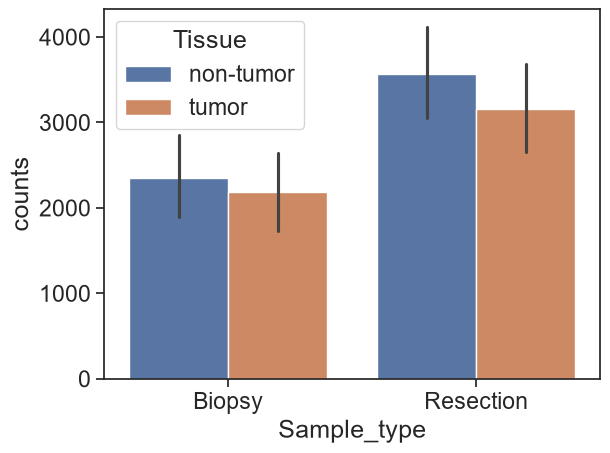

In [91]:
sns.barplot(data=metadata_qc, x='Sample_type', y='counts', hue='Tissue')

plt.savefig('phospho_proteomics_qc_site_ids.pdf', bbox_inches='tight', dpi=300)

In [92]:
res_list = []
for var in metadata_qc.Tissue.unique():
    subset = metadata_qc[metadata_qc.Tissue == var]
    print(var)
    res = stats.ttest_ind(subset[subset.Sample_type == 'Biopsy'].counts, subset[subset.Sample_type == 'Resection'].counts)
    print(res)
    print('\n')
    res_list.append(var)
    res_list.append(res)

    
import csv
    
with open('phospho_qc_ttest.csv', 'w', newline='') as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(res_list)

non-tumor
TtestResult(statistic=np.float64(-3.2345669823511085), pvalue=np.float64(0.005186715176952736), df=np.float64(16.0))


tumor
TtestResult(statistic=np.float64(-2.6429926590884434), pvalue=np.float64(0.017720620907310507), df=np.float64(16.0))




In [93]:
df_ff.head()

,non-tumor_Biopsy_D,tumor_Biopsy_D,non-tumor_Biopsy_N,tumor_Biopsy_N,non-tumor_Biopsy_O,tumor_Biopsy_O,non-tumor_Biopsy_Q,tumor_Biopsy_Q,non-tumor_Biopsy_I,tumor_Biopsy_I,non-tumor_Biopsy_T,tumor_Biopsy_T,non-tumor_Biopsy_U,tumor_Biopsy_U,non-tumor_Resection_D,tumor_Resection_D,non-tumor_Resection_N,tumor_Resection_N,non-tumor_Resection_O,tumor_Resection_O,non-tumor_Resection_Q,tumor_Resection_Q,non-tumor_Resection_T,tumor_Resection_T,non-tumor_Resection_I,tumor_Resection_I,non-tumor_Resection_U,tumor_Resection_U,non-tumor_Biopsy_L,tumor_Biopsy_L,non-tumor_Biopsy_E,tumor_Biopsy_E,non-tumor_Resection_L,tumor_Resection_L,non-tumor_Resection_E,tumor_Resection_E
site_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
RAMACL_S36,NaN,NaN,15.717055,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.046112,NaN,17.620327,15.910036,NaN,NaN,NaN,15.485933,16.230182,14.67789,18.437533,NaN,NaN,NaN,18.128296,NaN,18.715151,18.609211,18.943728,16.522493
SLC12A8_S665,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E2F8_T58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.721974,NaN
E2F8_S71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.854649,NaN,NaN,NaN,18.184691,NaN
ESYT2_S678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [94]:
df_ff['Gene'] = df_ff.index.str.split('_').str[0]
df_proteins = df_ff.groupby('Gene').sum()
df_proteins = df_proteins.replace(0, np.nan)
df_proteins.head()

,non-tumor_Biopsy_D,tumor_Biopsy_D,non-tumor_Biopsy_N,tumor_Biopsy_N,non-tumor_Biopsy_O,tumor_Biopsy_O,non-tumor_Biopsy_Q,tumor_Biopsy_Q,non-tumor_Biopsy_I,tumor_Biopsy_I,non-tumor_Biopsy_T,tumor_Biopsy_T,non-tumor_Biopsy_U,tumor_Biopsy_U,non-tumor_Resection_D,tumor_Resection_D,non-tumor_Resection_N,tumor_Resection_N,non-tumor_Resection_O,tumor_Resection_O,non-tumor_Resection_Q,tumor_Resection_Q,non-tumor_Resection_T,tumor_Resection_T,non-tumor_Resection_I,tumor_Resection_I,non-tumor_Resection_U,tumor_Resection_U,non-tumor_Biopsy_L,tumor_Biopsy_L,non-tumor_Biopsy_E,tumor_Biopsy_E,non-tumor_Resection_L,tumor_Resection_L,non-tumor_Resection_E,tumor_Resection_E
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A1CF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAGAB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAK1,39.1581,20.639005,107.830688,83.357943,59.261457,35.261171,38.132513,84.840412,39.514897,37.862471,36.692807,16.641022,16.813556,81.770925,91.741216,56.184562,99.565618,75.478449,138.313316,89.302449,78.530317,72.74349,74.985182,76.990511,91.875985,89.304118,72.824563,37.788381,36.334003,19.17955,81.772678,76.552978,100.379173,100.477349,101.476294,95.014368
AATF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.518334,NaN,16.603674,NaN,NaN,NaN,NaN,14.084775,13.692005,NaN,16.026765,NaN,NaN,NaN,17.036571,NaN,17.556985,15.700364,17.348694,NaN
ABCB11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.566500,37.777036,NaN,NaN,NaN,19.880601,NaN,19.05987,19.515309,39.144421,38.789905,19.124313,NaN,NaN,NaN,NaN,NaN,17.208396,18.514575,NaN,NaN,17.875659


In [95]:
metadata_qc['protein_counts'] = df_proteins.shape[0] - df_proteins.isna().sum()

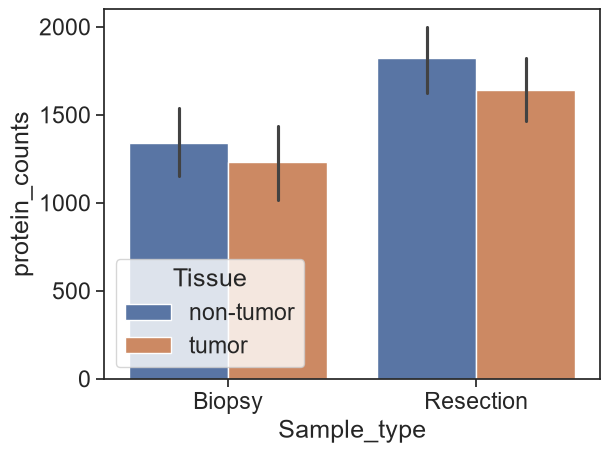

In [96]:
sns.barplot(data=metadata_qc, x='Sample_type', y='protein_counts', hue='Tissue')

plt.savefig('phospho_proteins_qc.pdf', bbox_inches='tight', dpi=300)

In [97]:
res_list = []
for var in metadata_qc.Tissue.unique():
    subset = metadata_qc[metadata_qc.Tissue == var]
    print(var)
    res = stats.ttest_ind(subset[subset.Sample_type == 'Biopsy'].protein_counts,
                          subset[subset.Sample_type == 'Resection'].protein_counts)
    print(res)
    print('\n')
    res_list.append(var)
    res_list.append(res)

    
import csv
    
with open('phospho_proteins_qc_ttest.csv', 'w', newline='') as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(res_list)

non-tumor
TtestResult(statistic=np.float64(-3.169583825492464), pvalue=np.float64(0.005945704343048616), df=np.float64(16.0))


tumor
TtestResult(statistic=np.float64(-2.7184762585747153), pvalue=np.float64(0.015185916833778927), df=np.float64(16.0))




## 7. Split non-tumor and HCC matrices

Create tissue-specific matrices aligned to their metadata.

In [98]:
df_liver = df_ff.loc[:,metadata_liver.col_names].copy()

df_hcc = df_ff.loc[:,metadata_hcc.col_names].copy()

## 8. Missingness filtering and KNN imputation

Require sufficient observed values and impute biopsy and resection groups separately using three-neighbor KNN.

In [99]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(
    n_neighbors=3,     # small k due to small sample size
    weights='uniform', # or 'distance' if closer samples should weigh more
    metric='nan_euclidean',  # default metric, handles missing values
    add_indicator=True
)
imputer_ = KNNImputer(
    n_neighbors=3,     # small k due to small sample size
    weights='uniform', # or 'distance' if closer samples should weigh more
    metric='nan_euclidean',  # default metric, handles missing values
    add_indicator=False
)
imputer.set_output(transform='pandas')
imputer_.set_output(transform='pandas')

,"n_neighbors n_neighbors: int, default=5Number of neighboring samples to use for imputation.",3
,"missing_values missing_values: int, float, str, np.nan or None, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to np.nan, since `pd.NA` will be converted to np.nan.",nan
,"weights weights: {'uniform', 'distance'} or callable, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- callable : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.",'uniform'
,"metric metric: {'nan_euclidean'} or callable, default='nan_euclidean'Distance metric for searching neighbors. Possible values:- 'nan_euclidean'- callable : a user-defined function which conforms to the definition of ``func_metric(x, y, *, missing_values=np.nan)``. `x` and `y` corresponds to a row (i.e. 1-D arrays) of `X` and `Y`, respectively. The callable should returns a scalar distance value.",'nan_euclidean'
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto theoutput of the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear on themissing indicator even if there are missing values at transform/testtime.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0`... versionadded:: 1.2",False


In [100]:
# at least 4 valid values
df_liver = df_liver.dropna(thresh=4)
df_hcc = df_hcc.dropna(thresh=4)
print(df_liver.shape)

# at least one valid value per condition
df_liver = df_liver.dropna(thresh=1, subset=metadata_liver[metadata_liver.Sample_type == 'Biopsy'].col_names)
df_liver = df_liver.dropna(thresh=1, subset=metadata_liver[metadata_liver.Sample_type == 'Resection'].col_names)
print(df_liver.shape)

df_hcc = df_hcc.dropna(thresh=1, subset=metadata_hcc[metadata_hcc.Sample_type == 'Biopsy'].col_names)
df_hcc = df_hcc.dropna(thresh=1, subset=metadata_hcc[metadata_hcc.Sample_type == 'Resection'].col_names)

(4462, 18)
(4037, 18)


In [101]:
df_liver.shape

(4037, 18)

In [102]:
df_hcc.shape

(3457, 18)

In [103]:
df_liver_biop = imputer.fit_transform(df_liver.loc[:,metadata_liver[metadata_liver.Sample_type == 'Biopsy'].col_names])
df_liver_rese = imputer.fit_transform(df_liver.loc[:,metadata_liver[metadata_liver.Sample_type == 'Resection'].col_names])

df_hcc_biop = imputer.fit_transform(df_hcc.loc[:,metadata_hcc[metadata_hcc.Sample_type == 'Biopsy'].col_names])
df_hcc_rese = imputer.fit_transform(df_hcc.loc[:,metadata_hcc[metadata_hcc.Sample_type == 'Resection'].col_names])


# For PCA with all samples
df_all = pd.concat([df_liver_biop, df_liver_rese, df_hcc_biop, df_hcc_rese], axis=1)
df_all = df_all.loc[:,[x for x in df_all.columns if not x.startswith('missing')]]
df_all = imputer_.fit_transform(df_all)

In [104]:
df_liver_imputed = pd.concat([df_liver_biop, df_liver_rese], axis=1)
#df_liver_imputed['Gene'] = df_liver_imputed.index.map(df_liver.Gene)
df_liver_imputed.to_csv('phospho_imputed_liver.csv')

df_hcc_imputed = pd.concat([df_hcc_biop, df_hcc_rese], axis=1)
#df_hcc_imputed['Gene'] = df_hcc_imputed.index.map(df_hcc.Gene)
df_hcc_imputed.to_csv('phospho_imputed_hcc.csv')

## 9. Paired limma sensitivity analysis without imputation

Fit patient-blocked empirical-Bayes models to features with sufficient complete pairs.

In [48]:
print("InMoose version:", version("inmoose"))


# Columns already visible in your code
SAMPLE_COL = "col_names"
METHOD_COL = "Sample_type"

# Replace this with the exact participant/patient column in your metadata
PARTICIPANT_COL = "patient_id"

REFERENCE_METHOD = "Biopsy"
COMPARISON_METHOD = "Resection"

InMoose version: 0.9.1


In [49]:
def _standardize_inmoose_columns(results):
    """
    Standardize column names across different InMoose versions.
    """

    rename_map = {
        # Effect size
        "logFC": "log2FoldChange",

        # Moderated statistic
        "t": "stat",

        # Raw p-value
        "P.Value": "pvalue",
        "P_Value": "pvalue",

        # Adjusted p-value
        "adj.P.Val": "adj_pvalue",
        "adj_P_Value": "adj_pvalue",
    }

    return results.rename(columns=rename_map)


def run_paired_limma(
    expression,
    metadata,
    *,
    sample_col,
    participant_col,
    method_col,
    reference="Biopsy",
    comparison="Resection",
    min_complete_pairs=4,
    trend=True,
    robust=True,
):
    """
    Paired limma analysis using within-participant differences.

    The tested quantity is:

        comparison - reference

    For example:

        Resection - Biopsy

    Parameters
    ----------
    expression : pandas.DataFrame
        Feature x sample matrix of original log2 intensities.
        Missing values must remain NaN. Do not use KNN-imputed values.

    metadata : pandas.DataFrame
        Sample metadata.

    sample_col : str
        Metadata column containing expression-matrix column names.

    participant_col : str
        Participant/patient identifier.

    method_col : str
        Collection-method column.

    reference : str
        Reference collection method.

    comparison : str
        Collection method compared against the reference.

    min_complete_pairs : int
        Minimum number of participants with both measurements available
        for a feature.

    trend : bool
        If True, estimate an abundance-dependent prior variance trend.

    robust : bool
        Use robust empirical-Bayes variance moderation.

    Returns
    -------
    dict
        results
        fit
        design
        matrix
        pair_table
        paired_samples
        filter_summary
    """

    # -------------------------------------------------------------
    # 1. Validate and standardize expression matrix
    # -------------------------------------------------------------

    expr = expression.copy()

    if expr.index.has_duplicates:
        duplicates = (
            expr.index[expr.index.duplicated()]
            .unique()
            .tolist()
        )

        raise ValueError(
            "Expression feature IDs are duplicated. "
            f"Examples: {duplicates[:10]}"
        )

    expr.columns = expr.columns.astype(str)

    expr = expr.apply(
        pd.to_numeric,
        errors="coerce",
    )

    expr = expr.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    # -------------------------------------------------------------
    # 2. Validate and subset metadata
    # -------------------------------------------------------------

    required_columns = [
        sample_col,
        participant_col,
        method_col,
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in metadata.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Metadata columns not found: {missing_columns}"
        )

    md = metadata[required_columns].copy()

    md = md.dropna(
        subset=required_columns
    )

    md[sample_col] = md[sample_col].astype(str)
    md[participant_col] = md[participant_col].astype(str)
    md[method_col] = (
        md[method_col]
        .astype(str)
        .str.strip()
    )

    # Keep only samples present in the expression matrix
    md = md.loc[
        md[sample_col].isin(expr.columns)
    ].copy()

    # Keep only the two methods being compared
    md = md.loc[
        md[method_col].isin(
            [reference, comparison]
        )
    ].copy()

    if md.empty:
        raise ValueError(
            "No matching metadata samples were found."
        )

    # -------------------------------------------------------------
    # 3. Require one sample per participant and method
    # -------------------------------------------------------------

    duplicated_pairs = md.duplicated(
        subset=[
            participant_col,
            method_col,
        ],
        keep=False,
    )

    if duplicated_pairs.any():
        duplicate_table = md.loc[
            duplicated_pairs,
            [
                sample_col,
                participant_col,
                method_col,
            ],
        ].sort_values(
            [
                participant_col,
                method_col,
            ]
        )

        raise ValueError(
            "More than one sample was found for at least one "
            "participant/method combination. Aggregate technical "
            "replicates first.\n\n"
            f"{duplicate_table}"
        )

    # -------------------------------------------------------------
    # 4. Match paired samples
    # -------------------------------------------------------------

    pair_table = md.pivot(
        index=participant_col,
        columns=method_col,
        values=sample_col,
    )

    if reference not in pair_table.columns:
        raise ValueError(
            f"No '{reference}' samples were found."
        )

    if comparison not in pair_table.columns:
        raise ValueError(
            f"No '{comparison}' samples were found."
        )

    pair_table = pair_table.dropna(
        subset=[
            reference,
            comparison,
        ]
    )

    if pair_table.empty:
        raise ValueError(
            "No participants had both collection methods."
        )

    # Expression columns used in the analysis
    paired_samples = []

    for participant in pair_table.index:
        paired_samples.extend(
            [
                pair_table.loc[
                    participant,
                    reference,
                ],
                pair_table.loc[
                    participant,
                    comparison,
                ],
            ]
        )

    # -------------------------------------------------------------
    # 5. Calculate within-participant differences
    # -------------------------------------------------------------

    paired_differences = pd.DataFrame(
        index=expr.index
    )

    for participant, pair in pair_table.iterrows():

        reference_sample = pair[reference]
        comparison_sample = pair[comparison]

        paired_differences[participant] = (
            expr[comparison_sample]
            - expr[reference_sample]
        )

    # A difference is NaN when either member of the pair is missing
    n_complete_pairs = (
        paired_differences
        .notna()
        .sum(axis=1)
        .astype(int)
    )

    keep = (
        n_complete_pairs
        >= min_complete_pairs
    )

    tested_differences = (
        paired_differences
        .loc[keep]
        .copy()
    )

    if tested_differences.empty:
        raise ValueError(
            "No features passed the minimum complete-pair threshold."
        )

    # -------------------------------------------------------------
    # 6. Calculate abundance for limma-trend
    # -------------------------------------------------------------

    raw_paired_matrix = expr.loc[
        tested_differences.index,
        paired_samples,
    ]

    mean_log2_intensity = (
        raw_paired_matrix
        .mean(axis=1, skipna=True)
    )

    # For an intercept-only difference model, the default Amean from
    # lmFit would be the mean difference, not the mean abundance.
    # Therefore, explicitly provide mean abundance as the trend
    # covariate.
    if trend:
        trend_argument = (
            mean_log2_intensity
            .to_numpy(dtype=float)
        )
    else:
        trend_argument = False

    # -------------------------------------------------------------
    # 7. Intercept-only paired-difference model
    # -------------------------------------------------------------
    
    design_metadata = pd.DataFrame(
        {
            "paired_difference": np.ones(
                tested_differences.shape[1],
                dtype=float,
            )
        },
        index=tested_differences.columns,
    )
    
    # Keep this as a Patsy DesignMatrix so InMoose preserves
    # the coefficient name in design_info.
    design = dmatrix(
        "0 + paired_difference",
        data=design_metadata,
        return_type="matrix",
    )
    
    fit = lmFit(
        tested_differences,
        design=design,
    )
    
    fit = eBayes(
        fit,
        trend=trend_argument,
        robust=False,
    )
    
    
    # -------------------------------------------------------------
    # 8. Extract all tested features
    # -------------------------------------------------------------
    
    # Do not assume that InMoose retained a specific name.
    # Read the actual coefficient name from the fitted object.
    coefficient_names = fit.coefficients.columns.tolist()
    
    if len(coefficient_names) != 1:
        raise RuntimeError(
            "Expected exactly one coefficient in the paired-difference "
            f"model, but found: {coefficient_names}"
        )
    
    method_coefficient = coefficient_names[0]
    
    print(
        "Coefficient tested by topTable:",
        method_coefficient,
    )
    
    results = topTable(
        fit,
        coef=method_coefficient,
        number=tested_differences.shape[0],
        adjust_method="fdr_bh",
        sort_by="P",
        p_value=1.0,
    )
    
    results = pd.DataFrame(results)
    results = _standardize_inmoose_columns(results)

    # -------------------------------------------------------------
    # 9. Add missingness diagnostics
    # -------------------------------------------------------------

    diagnostics = pd.DataFrame(
        index=tested_differences.index
    )

    diagnostics["n_complete_pairs"] = (
        n_complete_pairs.loc[
            tested_differences.index
        ]
    )

    diagnostics["n_incomplete_pairs"] = (
        pair_table.shape[0]
        - diagnostics["n_complete_pairs"]
    )

    diagnostics["incomplete_pair_fraction"] = (
        diagnostics["n_incomplete_pairs"]
        / pair_table.shape[0]
    )

    diagnostics["n_raw_observed_values"] = (
        raw_paired_matrix
        .notna()
        .sum(axis=1)
    )

    diagnostics["n_raw_missing_values"] = (
        raw_paired_matrix
        .isna()
        .sum(axis=1)
    )

    diagnostics["raw_missing_fraction"] = (
        raw_paired_matrix
        .isna()
        .mean(axis=1)
    )

    diagnostics["mean_log2_intensity"] = (
        mean_log2_intensity
    )

    results = diagnostics.join(
        results,
        how="left",
    )

    results["effect"] = (
        f"{comparison} - {reference}"
    )

    if "adj_pvalue" in results.columns:
        results["significant_FDR_0.05"] = (
            results["adj_pvalue"] < 0.05
        )

        results = results.sort_values(
            [
                "adj_pvalue",
                "pvalue",
            ],
            na_position="last",
        )

    # -------------------------------------------------------------
    # 10. Analysis summary
    # -------------------------------------------------------------

    filter_summary = pd.Series(
        {
            "features_input": expr.shape[0],
            "features_tested": tested_differences.shape[0],
            "features_excluded": (
                expr.shape[0] - tested_differences.shape[0]
            ),
            "participants_with_both_methods": pair_table.shape[0],
            "minimum_complete_pairs": min_complete_pairs,
            "reference_method": reference,
            "comparison_method": comparison,
            "effect_definition": f"{comparison} - {reference}",
            "limma_coefficient": method_coefficient,
            "variance_moderation": "limma empirical Bayes",
            "robust_empirical_bayes": False,
            "abundance_trend": trend,
            "imputation_used_for_testing": False,
        },
        name="analysis_summary",
    )

    return {
        "results": results,
        "fit": fit,
        "design": pd.DataFrame(
            np.asarray(design),
            index=tested_differences.columns,
            columns=design.design_info.column_names,
        ),
        "matrix": tested_differences,
        "all_differences": paired_differences,
        "pair_table": pair_table,
        "paired_samples": paired_samples,
        "mean_log2_intensity": mean_log2_intensity,
        "filter_summary": filter_summary,
    }

In [50]:
liver_limma = run_paired_limma(
    expression=df_liver,
    metadata=metadata_liver,
    sample_col=SAMPLE_COL,
    participant_col=PARTICIPANT_COL,
    method_col=METHOD_COL,
    reference="Biopsy",
    comparison="Resection",
    min_complete_pairs=4,
    trend=True,
    robust=False, # not implemented
)

Coefficient tested by topTable: paired_difference


In [51]:
hcc_limma = run_paired_limma(
    expression=df_hcc,
    metadata=metadata_hcc,
    sample_col=SAMPLE_COL,
    participant_col=PARTICIPANT_COL,
    method_col=METHOD_COL,
    reference="Biopsy",
    comparison="Resection",
    min_complete_pairs=4,
    trend=True,
    robust=False, #not implemented
)

Coefficient tested by topTable: paired_difference


## 10. PCA overview

Fit global PCA after scaling and inspect the contribution of sample type, tissue, and patient.

In [107]:
df_all_pca = df_all.copy()
df_all_pca['expression_std'] = df_all_pca.std(axis=1)
df_all_pca = df_all_pca.sort_values('expression_std', ascending=False)
df_all_pca = df_all_pca.iloc[:500,:-1]
df_all_pca.head()

,non-tumor_Biopsy_D,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_I,non-tumor_Biopsy_T,non-tumor_Biopsy_U,non-tumor_Biopsy_L,non-tumor_Biopsy_E,non-tumor_Resection_D,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,non-tumor_Resection_I,non-tumor_Resection_U,non-tumor_Resection_L,non-tumor_Resection_E,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_U,tumor_Biopsy_L,tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_U,tumor_Resection_L,tumor_Resection_E
site_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
UGDH_S476,20.261071,18.194540,21.294106,15.950827,18.701296,19.089091,13.253351,21.412578,19.829738,27.030601,26.994306,25.645960,25.540307,27.186824,25.378549,25.262435,28.153595,26.896083,18.746445,17.134657,16.608408,16.569626,19.415882,16.934553,14.648217,18.539053,18.630797,26.277348,22.211619,26.221329,26.289499,25.063495,26.304978,19.270231,25.355409,28.448096
TAGLN2_S163,18.790224,18.063211,21.077546,17.669612,19.938954,19.081933,17.828487,19.590099,18.797734,24.678069,24.752564,24.859076,20.440119,24.695740,23.794615,24.492442,24.228899,24.983062,18.069125,15.479884,16.440176,16.649916,17.309610,15.741326,15.674904,16.725108,17.814332,23.901262,22.226069,23.441277,23.393817,23.881794,23.766411,18.359784,23.215001,24.623164
HSP90AB1_S226,20.442155,21.748431,20.212910,19.570043,20.880673,19.227303,17.467799,19.097711,22.182448,15.384187,16.521403,16.044181,19.485372,15.067087,17.850498,18.163242,24.623125,26.102053,19.997168,15.811130,15.493165,16.002756,15.785694,16.203734,16.671483,16.324067,22.614704,16.288848,17.401427,19.331085,18.440550,18.162777,17.855848,18.591825,24.521596,25.746726
TRIM28_S473,14.286832,19.565048,16.430898,18.034637,19.871522,15.725497,18.466111,14.316472,20.044642,22.024192,23.172008,20.068337,19.737810,18.975011,20.598443,21.819768,21.997348,21.664446,14.892991,12.999058,16.150508,15.538352,15.001914,15.404143,15.834649,17.919473,16.385241,21.511169,20.898973,20.903541,20.324260,22.394226,20.504371,20.736044,22.660725,22.773996
CCDC86_S47,21.736163,21.487625,21.864435,21.311190,21.580086,23.432524,22.498084,21.313516,22.806908,19.396887,22.507646,21.807561,20.910904,16.720391,21.598834,25.763205,23.213356,20.860284,17.657539,17.962020,13.247009,17.397307,17.829266,18.551009,18.105003,17.045443,21.982377,19.297662,21.292197,13.550049,15.504860,15.304612,21.769706,19.024174,22.258733,20.841680


In [108]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_all_pca.T)
pca = PCA(n_components=10)

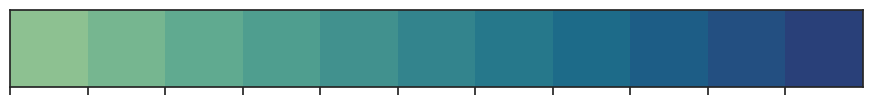

In [109]:
palette = sns.color_palette('crest', 11)
sns.palplot(palette)
plt.savefig('pca_tissue_composition_cmap.pdf')
plt.show()

In [111]:
metadata.index = metadata.col_names

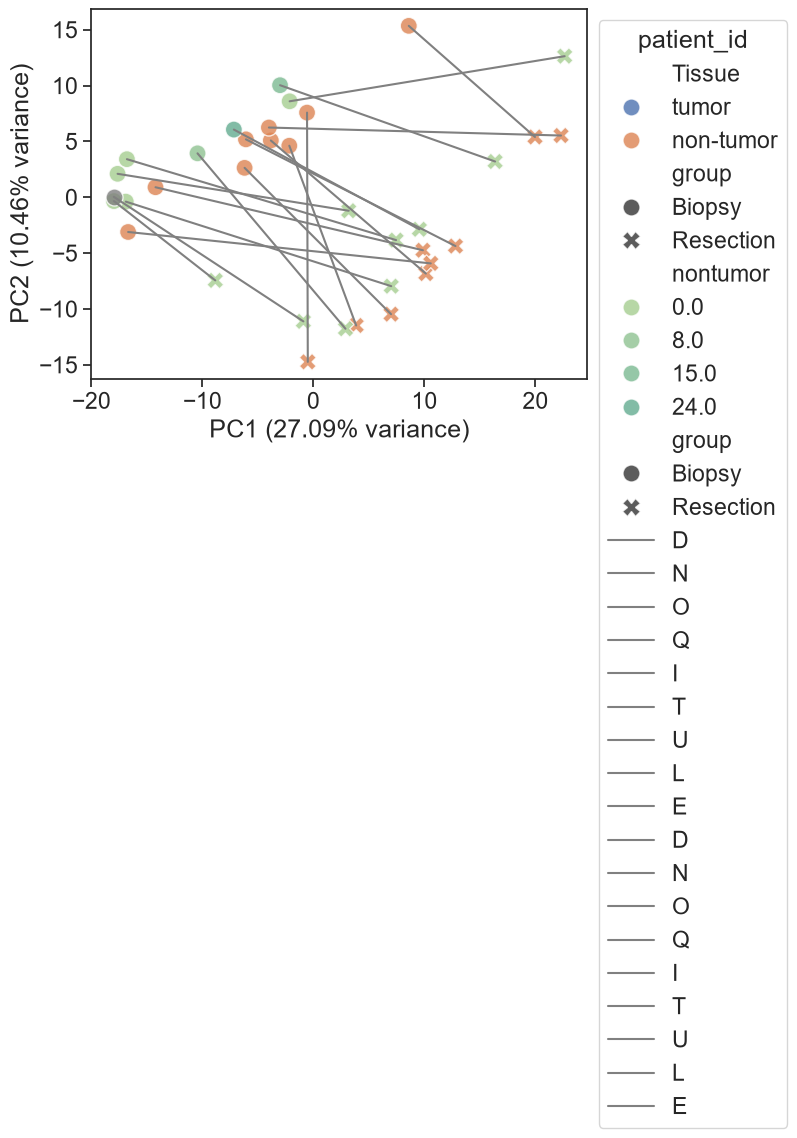

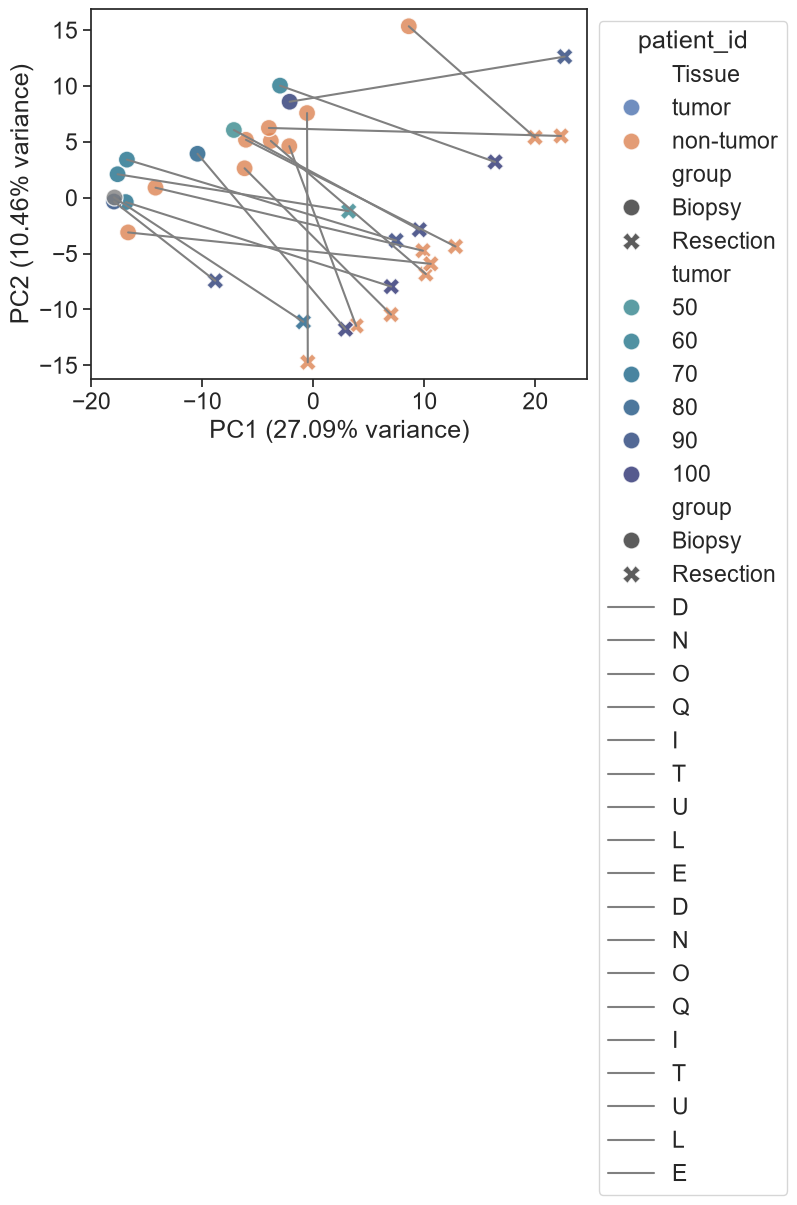

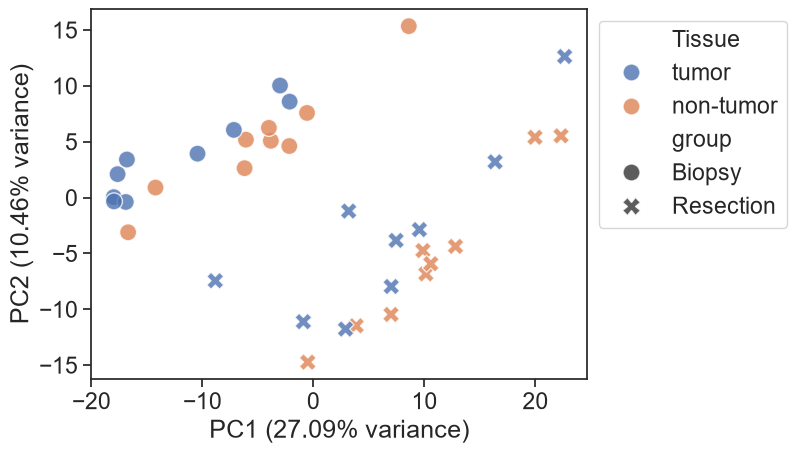

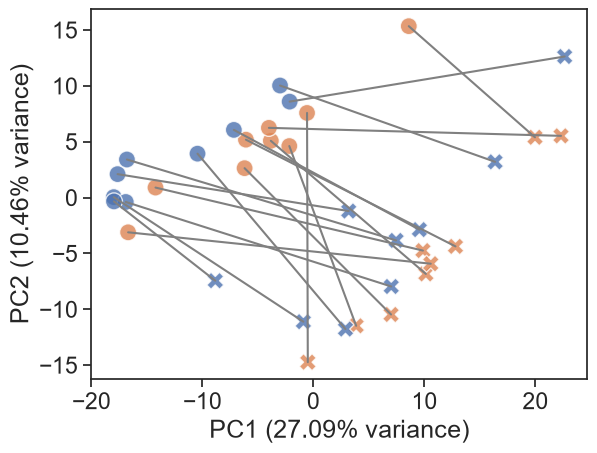

In [112]:
projections = pca.fit_transform(scaled_data)

df_pca = pd.DataFrame(projections, columns=[f'PC{x}' for x in range(1,11)], index=df_all_pca.columns)
df_pca['group'] = metadata.Sample_type
df_pca['Tissue'] = metadata.Tissue
df_pca['sex'] = metadata.Sex
df_pca['patient_id'] = metadata.patient_id.astype(str)

for col in ["nontumor", "tumor"]:
    df_pca[col] = metadata[col]

    fig, ax = plt.subplots()
    g = sns.scatterplot(df_pca[df_pca.Tissue == 'non-tumor'], x='PC1', y='PC2', hue='Tissue', style='group',
                        ax=ax, s=150, alpha=0.8, hue_order=['tumor', 'non-tumor'])
    j = sns.scatterplot(df_pca[df_pca.Tissue == 'tumor'].dropna(), x='PC1', y='PC2', hue_norm=(0,100),
                        hue=col, style='group', ax=ax, s=150, alpha=0.8, palette='crest')
    k = sns.scatterplot(df_pca[(df_pca.Tissue == 'tumor') & (df_pca[col].isna())], x='PC1', y='PC2',c=sns.color_palette(['gray']),
                        ax=ax, s=150, alpha=0.8)
    h = sns.lineplot(df_pca[df_pca.Tissue == 'tumor'], x='PC1', y='PC2', 
                     hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
    i = sns.lineplot(df_pca[df_pca.Tissue == 'non-tumor'], x='PC1', y='PC2',
                     hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
    #plt.legend([],[], frameon=False)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
    plt.savefig(f'figures/PCA_all_{col}.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

    

# Overview
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='Tissue', style='group',
                    ax=ax, s=150, alpha=0.8, hue_order=['tumor', 'non-tumor'])
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_all.pdf', bbox_inches='tight', dpi=300)
plt.show()
plt.close()

# Patients
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='Tissue', style='group',
                    ax=ax, s=150, alpha=0.8, hue_order=['tumor', 'non-tumor'])
h = sns.lineplot(df_pca[df_pca.Tissue == 'tumor'], x='PC1', y='PC2',
                 hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
i = sns.lineplot(df_pca[df_pca.Tissue == 'non-tumor'], x='PC1', y='PC2',
                 hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
plt.legend([],[], frameon=False)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.savefig('figures/PCA_all_pat.pdf', bbox_inches='tight', dpi=300)
plt.show()
plt.close()

In [113]:
scaler = StandardScaler()
pca = PCA(n_components=10)

In [114]:
hue_order=['Biopsy', 'Resection']

In [115]:
metadata_liver.index = metadata_liver.col_names

metadata_hcc.index = metadata_hcc.col_names

## 11. Non-tumor PCA and paired distances

Visualize non-tumor sample structure and benchmark within-patient biopsy/resection displacement.

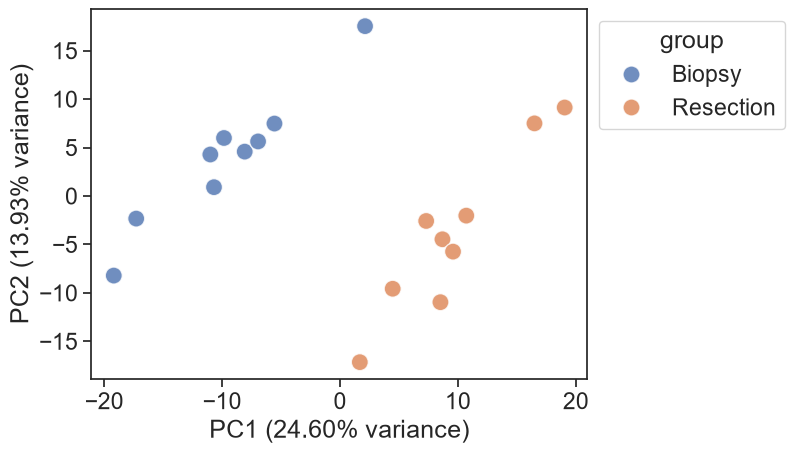

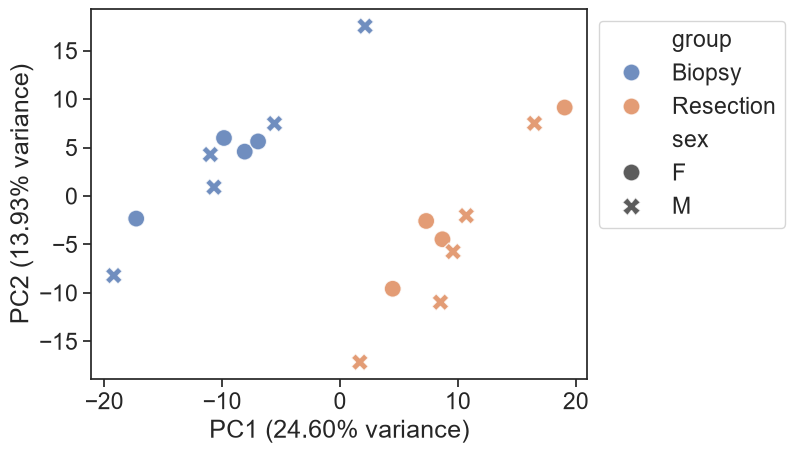

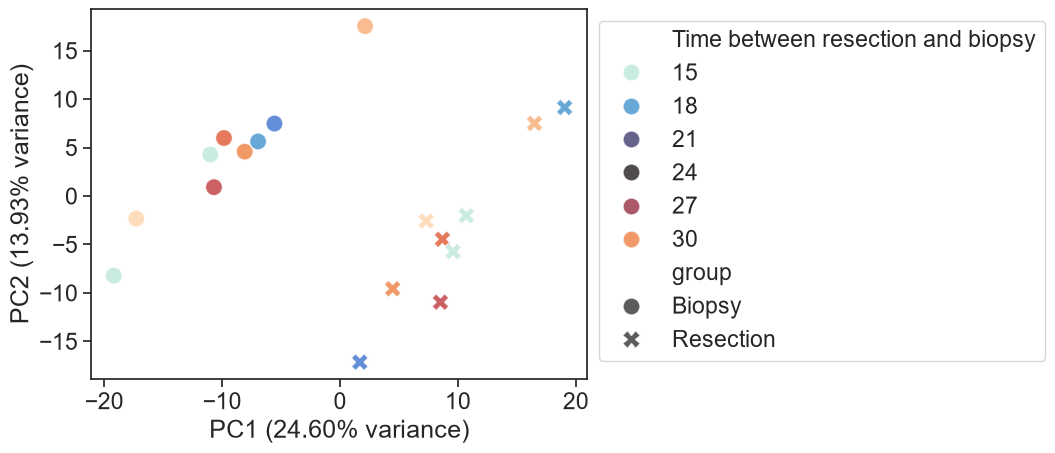

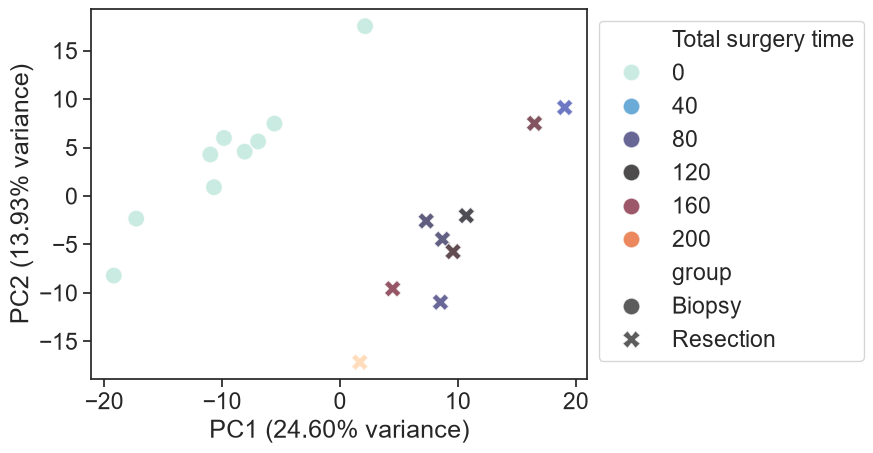

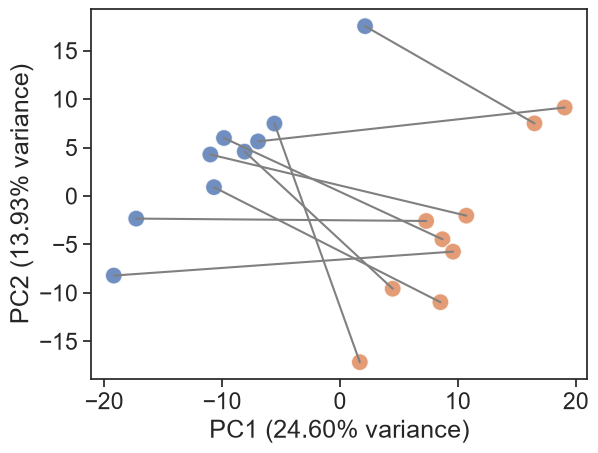

In [116]:
# PCA
used_cols = [x for x in df_liver_imputed.columns if x.startswith('non-tumor')]


# Most variable proteins
df_liver_pca = df_liver_imputed.loc[:,used_cols].copy()
df_liver_pca['abs_std'] = df_liver_pca.std(axis=1)
df_liver_pca = df_liver_pca.sort_values('abs_std', ascending=False)
df_liver_pca = df_liver_pca.iloc[:500,:-1]

scaled = scaler.fit_transform(df_liver_pca.T)

pca_data = pca.fit_transform(scaled)

df_pca = pd.DataFrame(pca_data, index=used_cols, columns=[f'PC{x}' for x in range (1,11)])
df_pca['group'] = metadata_liver.Sample_type
df_pca['sex'] = metadata_liver.Sex
df_pca['patient_id'] = metadata_liver.patient_id.astype(str)
df_pca['Time between resection and biopsy'] = metadata_liver['Time between resection and biopsy']
df_pca['Total surgery time'] = metadata_liver['Total surgery time']

# Overview
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_liver_{today}.pdf', bbox_inches='tight', dpi=300)

#plt.show()

# Sex
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='sex',
                    hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_liver_sex_{today}.pdf', bbox_inches='tight', dpi=300)

# Time between B and R
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='group',
                    hue='Time between resection and biopsy', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_liver_timeBvR_{today}.pdf', bbox_inches='tight', dpi=300)

# Surgery time
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='group',
                    hue='Total surgery time', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_liver_surgerytime_{today}.pdf', bbox_inches='tight', dpi=300)

# Patients
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
h = sns.lineplot(df_pca, x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
plt.legend([],[], frameon=False)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.savefig(f'figures/PCA_liver_pat_{today}.pdf', bbox_inches='tight', dpi=300)

In [54]:
def r2(x, y, ax=None, **kws):
    ax = ax or plt.gca()
    mask = ~np.isnan(x) & ~np.isnan(y)
    slope, intercept, r_value, p_value, std_err = linregress(x[mask], y[mask])
    ax.annotate(f'$r^2 = {r_value ** 2:.2f}$\nEq: ${slope:.2f}x{intercept:+.2f}$\np: ${p_value :.2E}$',
                xy=(.05, .95), xycoords=ax.transAxes, fontsize=8,
                color='darkred', backgroundcolor='#FFFFFF99', ha='left', va='top')

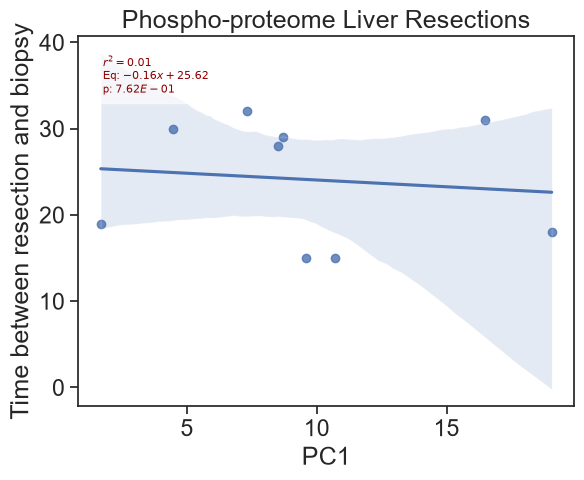

In [55]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Time between resection and biopsy')
r2(df_pca_biop.PC1, df_pca_biop['Time between resection and biopsy'])

plt.title('Phospho-proteome Liver Resections')


plt.savefig(f'figures/corr_pc1_time_b_to_r_{today}.pdf', dpi=300, bbox_inches='tight')

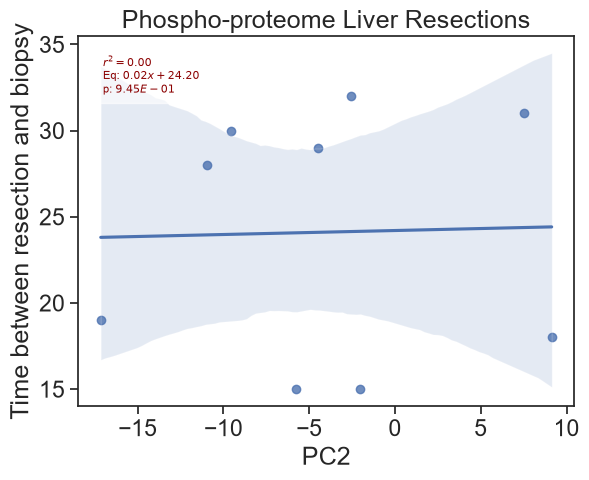

In [56]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Time between resection and biopsy')
r2(df_pca_biop.PC2, df_pca_biop['Time between resection and biopsy'])

plt.title('Phospho-proteome Liver Resections')


plt.savefig(f'figures/corr_pc2_time_b_to_r_{today}.pdf', dpi=300, bbox_inches='tight')

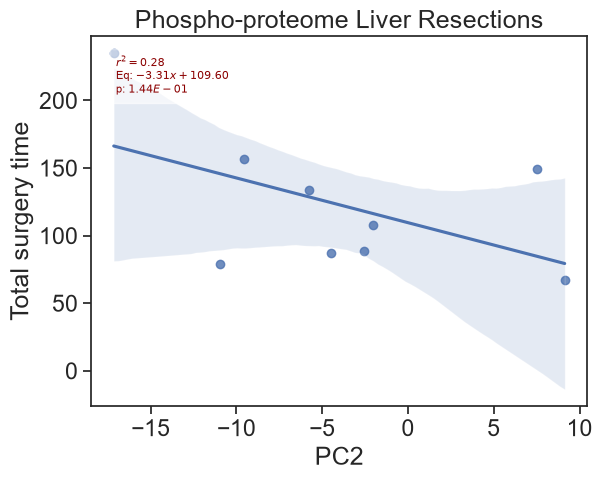

In [57]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Total surgery time')
r2(df_pca_biop.PC2, df_pca_biop['Total surgery time'])

plt.title('Phospho-proteome Liver Resections')

plt.savefig(f'figures/corr_pc2_time_surgery_{today}.pdf', dpi=300, bbox_inches='tight')

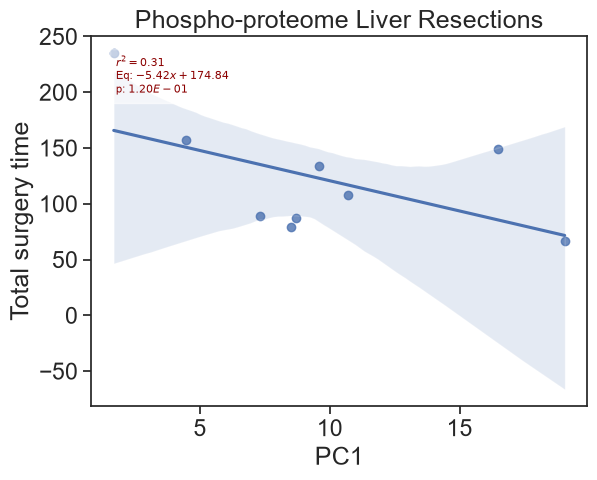

In [58]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Total surgery time')
r2(df_pca_biop.PC1, df_pca_biop['Total surgery time'])

plt.title('Phospho-proteome Liver Resections')

plt.savefig(f'figures/corr_pc1_time_surgery_{today}.pdf', dpi=300, bbox_inches='tight')

In [59]:
def paired_distance_magnitude(
    scores,
    meta,
    patient_col="Patient ID",
    sample_type_col="Sample_type",
    biopsy_label="Biopsy",
    resection_label="Resection",
    pc_cols=None,
):
    """
    Calculates paired biopsy-to-resection distances and patient centroids
    in PCA space.
    """

    if pc_cols is None:
        pc_cols = [c for c in scores.columns if c.startswith("PC")]

    meta = meta.loc[scores.index].copy()

    pair_rows = []
    centroid_rows = []

    for patient, m in meta.groupby(patient_col):

        biopsy_samples = m.index[m[sample_type_col] == biopsy_label].tolist()
        resection_samples = m.index[m[sample_type_col] == resection_label].tolist()

        if len(biopsy_samples) != 1 or len(resection_samples) != 1:
            continue

        b = biopsy_samples[0]
        r = resection_samples[0]

        b_vec = scores.loc[b, pc_cols].values.astype(float)
        r_vec = scores.loc[r, pc_cols].values.astype(float)

        diff = r_vec - b_vec
        dist = np.linalg.norm(diff)

        centroid = (b_vec + r_vec) / 2

        row = {
            patient_col: patient,
            "biopsy_sample": b,
            "resection_sample": r,
            "n_pcs": len(pc_cols),
            "paired_distance": dist,
        }

        for pc, value in zip(pc_cols, diff):
            row[f"{pc}_resection_minus_biopsy"] = value

        pair_rows.append(row)

        centroid_rows.append(
            pd.Series(centroid, index=pc_cols, name=patient)
        )

    paired_distances = pd.DataFrame(pair_rows)
    patient_centroids = pd.DataFrame(centroid_rows)

    return paired_distances, patient_centroids

def exhaustive_patient_blocked_collection_test(
    scores,
    meta,
    patient_col="Patient ID",
    sample_type_col="Sample_type",
    biopsy_label="Biopsy",
    resection_label="Resection",
    pc_cols=None,
):
    """
    Exact patient-blocked permutation test for paired Biopsy/Resection PCA scores.
    Enumerates all 2^n within-patient label swaps.

    Suitable when n_pairs is modest, e.g. <= 20.
    """

    if pc_cols is None:
        pc_cols = [c for c in scores.columns if c.startswith("PC")]

    meta = meta.loc[scores.index].copy()

    keep_samples = []
    patients_ordered = []

    for patient, m in meta.groupby(patient_col):
        biopsy_samples = m.index[m[sample_type_col] == biopsy_label].tolist()
        resection_samples = m.index[m[sample_type_col] == resection_label].tolist()

        if len(biopsy_samples) == 1 and len(resection_samples) == 1:
            keep_samples.extend([biopsy_samples[0], resection_samples[0]])
            patients_ordered.append(patient)

    meta = meta.loc[keep_samples].copy()
    Y = scores.loc[keep_samples, pc_cols].values

    patient_dummies = pd.get_dummies(meta[patient_col], drop_first=False)
    X_patient = patient_dummies.values.astype(float)

    collection_observed = (
        meta[sample_type_col].values == resection_label
    ).astype(float).reshape(-1, 1)

    def rss_multivariate_lm(Y, X):
        beta, *_ = np.linalg.lstsq(X, Y, rcond=None)
        resid = Y - X @ beta
        rss = np.sum(resid ** 2)
        rank = np.linalg.matrix_rank(X)
        df_resid = Y.shape[0] - rank
        return rss, df_resid, rank

    rss_patient, df_patient, rank_patient = rss_multivariate_lm(Y, X_patient)

    X_full_observed = np.column_stack([X_patient, collection_observed])
    rss_full_obs, df_full, rank_full = rss_multivariate_lm(Y, X_full_observed)

    ss_collection_obs = rss_patient - rss_full_obs
    partial_R2_obs = ss_collection_obs / rss_patient

    n_pairs = len(patients_ordered)

    perm_R2 = []

    # Precompute sample indices for each patient
    patient_to_indices = {
        patient: np.where(meta[patient_col].values == patient)[0]
        for patient in patients_ordered
    }

    for swap_pattern in itertools.product([0, 1], repeat=n_pairs):

        collection_perm = collection_observed.copy()

        for patient, swap in zip(patients_ordered, swap_pattern):
            if swap == 1:
                idx = patient_to_indices[patient]
                collection_perm[idx] = 1 - collection_perm[idx]

        X_perm = np.column_stack([X_patient, collection_perm])
        rss_perm_full, _, _ = rss_multivariate_lm(Y, X_perm)

        ss_perm_collection = rss_patient - rss_perm_full
        perm_R2.append(ss_perm_collection / rss_patient)

    perm_R2 = np.array(perm_R2)

    exact_p = np.mean(perm_R2 >= partial_R2_obs - 1e-12)

    result = {
        "n_pairs": n_pairs,
        "n_samples": meta.shape[0],
        "n_pcs": len(pc_cols),
        "observed_partial_R2": partial_R2_obs,
        "observed_partial_R2_percent": 100 * partial_R2_obs,
        "exact_permutation_p_value": exact_p,
        "n_total_permutations": len(perm_R2),
        "n_permutations_ge_observed": int(np.sum(perm_R2 >= partial_R2_obs - 1e-12)),
        "max_permuted_partial_R2": np.max(perm_R2),
        "max_permuted_partial_R2_percent": 100 * np.max(perm_R2),
    }

    return result, perm_R2

In [60]:
K = 10
pc_cols = [f"PC{i+1}" for i in range(K)]

# scores,
# meta,
# patient_col="Patient ID",
# sample_type_col="Sample_type",
# biopsy_label="Biopsy",
# resection_label="Resection",

paired_distances, patient_centroids = paired_distance_magnitude(
    scores=df_pca,
    meta=metadata_liver,
    patient_col='patient_id',
    sample_type_col='Sample_type',
    biopsy_label='Biopsy',
    resection_label='Resection',
    pc_cols=pc_cols,
)

paired_distances

,patient_id,biopsy_sample,resection_sample,n_pcs,paired_distance,PC1_resection_minus_biopsy,PC2_resection_minus_biopsy,PC3_resection_minus_biopsy,PC4_resection_minus_biopsy,PC5_resection_minus_biopsy,PC6_resection_minus_biopsy,PC7_resection_minus_biopsy,PC8_resection_minus_biopsy,PC9_resection_minus_biopsy,PC10_resection_minus_biopsy
0,D,non-tumor_Biopsy_D,non-tumor_Resection_D,10,24.154839,18.529117,-10.456174,-2.748773,-6.749142,-6.276549,-0.295250,-3.077229,4.532623,-2.452527,-1.476048
1,E,non-tumor_Biopsy_E,non-tumor_Resection_E,10,26.256478,14.367632,-10.035213,-13.240826,5.381291,3.012876,9.249697,7.425123,2.351877,-2.189077,4.230886
2,I,non-tumor_Biopsy_I,non-tumor_Resection_I,10,28.245382,12.550074,-14.154175,-10.166314,-9.368531,2.621283,4.859029,-13.912334,-4.088902,1.257768,2.549082
3,L,non-tumor_Biopsy_L,non-tumor_Resection_L,10,33.860824,26.001057,3.502317,-0.861736,0.930891,-1.759734,13.070918,9.183511,-10.538173,-9.176216,-1.756874
4,N,non-tumor_Biopsy_N,non-tumor_Resection_N,10,23.883371,21.707644,-6.310628,1.544640,-1.803796,-4.332438,-4.158567,0.123652,0.649388,3.607002,-2.053984
5,O,non-tumor_Biopsy_O,non-tumor_Resection_O,10,25.092669,19.205066,-11.871916,2.120093,-1.525622,2.114422,-2.613953,-1.672259,2.016638,-0.512242,-9.726949
6,Q,non-tumor_Biopsy_Q,non-tumor_Resection_Q,10,30.845051,24.592817,-0.246676,15.981908,0.396851,-1.464219,-2.064394,4.516635,5.568104,-5.695796,-0.848088
7,T,non-tumor_Biopsy_T,non-tumor_Resection_T,10,31.595864,7.238898,-24.630894,-12.410243,-0.311802,-5.913614,-6.335552,4.707494,4.986309,6.158984,5.003778
8,U,non-tumor_Biopsy_U,non-tumor_Resection_U,10,38.949566,28.774739,2.472549,18.929536,11.384915,3.827546,-4.928425,-5.151778,-4.302791,8.650092,6.017266


In [61]:
between_patient_centroid_distances = pdist(
    patient_centroids.loc[:, pc_cols].values,
    metric="euclidean",
)

median_paired_distance = paired_distances["paired_distance"].median()
median_between_patient_distance = np.median(between_patient_centroid_distances)

magnitude_ratio = median_paired_distance / median_between_patient_distance

paired_distance_percentile = percentileofscore(
    between_patient_centroid_distances,
    median_paired_distance,
    kind="rank",
)

magnitude_summary = pd.DataFrame({
    "n_pairs": [paired_distances.shape[0]],
    "n_pcs": [K],
    "median_paired_distance": [median_paired_distance],
    "mean_paired_distance": [paired_distances["paired_distance"].mean()],
    "median_between_patient_centroid_distance": [median_between_patient_distance],
    "paired_to_between_patient_distance_ratio": [magnitude_ratio],
    "median_paired_distance_percentile_vs_between_patient": [paired_distance_percentile],
})

magnitude_summary

,n_pairs,n_pcs,median_paired_distance,mean_paired_distance,median_between_patient_centroid_distance,paired_to_between_patient_distance_ratio,median_paired_distance_percentile_vs_between_patient
0,9,10,28.245382,29.209338,20.680248,1.365814,97.222222


In [62]:
paired_distances["percentile_vs_between_patient_centroids"] = [
    percentileofscore(
        between_patient_centroid_distances,
        d,
        kind="rank",
    )
    for d in paired_distances["paired_distance"]
]

paired_distances["ratio_to_median_between_patient_distance"] = (
    paired_distances["paired_distance"] / median_between_patient_distance
)

paired_distances

,patient_id,biopsy_sample,resection_sample,n_pcs,paired_distance,PC1_resection_minus_biopsy,PC2_resection_minus_biopsy,PC3_resection_minus_biopsy,PC4_resection_minus_biopsy,PC5_resection_minus_biopsy,PC6_resection_minus_biopsy,PC7_resection_minus_biopsy,PC8_resection_minus_biopsy,PC9_resection_minus_biopsy,PC10_resection_minus_biopsy,percentile_vs_between_patient_centroids,ratio_to_median_between_patient_distance
0,D,non-tumor_Biopsy_D,non-tumor_Resection_D,10,24.154839,18.529117,-10.456174,-2.748773,-6.749142,-6.276549,-0.295250,-3.077229,4.532623,-2.452527,-1.476048,83.333333,1.168015
1,E,non-tumor_Biopsy_E,non-tumor_Resection_E,10,26.256478,14.367632,-10.035213,-13.240826,5.381291,3.012876,9.249697,7.425123,2.351877,-2.189077,4.230886,88.888889,1.269640
2,I,non-tumor_Biopsy_I,non-tumor_Resection_I,10,28.245382,12.550074,-14.154175,-10.166314,-9.368531,2.621283,4.859029,-13.912334,-4.088902,1.257768,2.549082,97.222222,1.365814
3,L,non-tumor_Biopsy_L,non-tumor_Resection_L,10,33.860824,26.001057,3.502317,-0.861736,0.930891,-1.759734,13.070918,9.183511,-10.538173,-9.176216,-1.756874,100.000000,1.637351
4,N,non-tumor_Biopsy_N,non-tumor_Resection_N,10,23.883371,21.707644,-6.310628,1.544640,-1.803796,-4.332438,-4.158567,0.123652,0.649388,3.607002,-2.053984,83.333333,1.154888
5,O,non-tumor_Biopsy_O,non-tumor_Resection_O,10,25.092669,19.205066,-11.871916,2.120093,-1.525622,2.114422,-2.613953,-1.672259,2.016638,-0.512242,-9.726949,83.333333,1.213364
6,Q,non-tumor_Biopsy_Q,non-tumor_Resection_Q,10,30.845051,24.592817,-0.246676,15.981908,0.396851,-1.464219,-2.064394,4.516635,5.568104,-5.695796,-0.848088,100.000000,1.491522
7,T,non-tumor_Biopsy_T,non-tumor_Resection_T,10,31.595864,7.238898,-24.630894,-12.410243,-0.311802,-5.913614,-6.335552,4.707494,4.986309,6.158984,5.003778,100.000000,1.527828
8,U,non-tumor_Biopsy_U,non-tumor_Resection_U,10,38.949566,28.774739,2.472549,18.929536,11.384915,3.827546,-4.928425,-5.151778,-4.302791,8.650092,6.017266,100.000000,1.883419


In [63]:
diff_cols = [f"{pc}_resection_minus_biopsy" for pc in pc_cols]

diff_matrix = paired_distances[diff_cols].values

mean_displacement_vector = diff_matrix.mean(axis=0)

mean_vector_length = np.linalg.norm(mean_displacement_vector)
mean_individual_distance = np.mean(
    np.linalg.norm(diff_matrix, axis=1)
)

directional_coherence = mean_vector_length / mean_individual_distance

direction_summary = pd.DataFrame({
    "n_pairs": [paired_distances.shape[0]],
    "n_pcs": [K],
    "mean_vector_length": [mean_vector_length],
    "mean_individual_paired_distance": [mean_individual_distance],
    "directional_coherence": [directional_coherence],
})

direction_summary

,n_pairs,n_pcs,mean_vector_length,mean_individual_paired_distance,directional_coherence
0,9,10,20.843044,29.209338,0.713575


In [64]:
patient_col = 'patient_id'
distance_col = 'paired_distance'

# Copy and sort patient-level distances
plot_df = paired_distances[[patient_col, distance_col]].copy()
plot_df = plot_df.sort_values(distance_col, ascending=True).reset_index(drop=True)

# Summary stats for paired distances
paired_median = plot_df[distance_col].median()
paired_q1 = plot_df[distance_col].quantile(0.25)
paired_q3 = plot_df[distance_col].quantile(0.75)

# Summary stats for between-patient centroid distances
between_median = np.median(between_patient_centroid_distances)
between_q1 = np.quantile(between_patient_centroid_distances, 0.25)
between_q3 = np.quantile(between_patient_centroid_distances, 0.75)

In [65]:
plot_df_norm = plot_df.copy()
plot_df_norm["relative_distance"] = plot_df_norm[distance_col] / between_median
plot_df_norm = plot_df_norm.sort_values("relative_distance", ascending=True).reset_index(drop=True)

In [66]:
plot_df_norm.mean(numeric_only=True)

paired_distance      29.209338
relative_distance     1.412427
dtype: float64

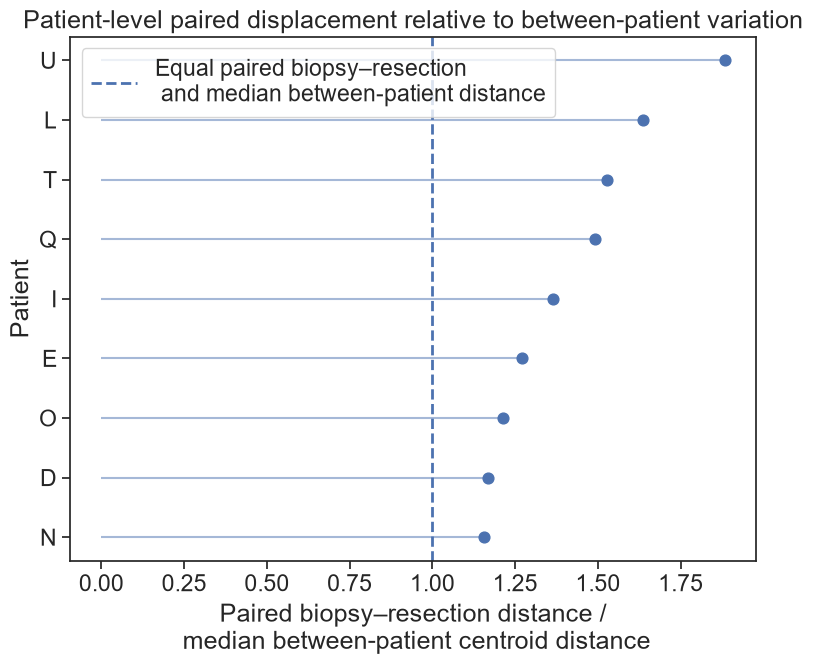

In [67]:
plt.figure(figsize=(8, 7))

y = np.arange(len(plot_df_norm))

# Summary stats for paired distances
paired_median = plot_df_norm[distance_col].median()

# Summary stats for between-patient centroid distances
between_median = np.median(between_patient_centroid_distances)

for yi, x in zip(y, plot_df_norm["relative_distance"]):
    plt.hlines(y=yi, xmin=0, xmax=x, linewidth=1.5, alpha=0.5)

plt.scatter(plot_df_norm["relative_distance"], y, s=60, zorder=3)

plt.axvline(1.0, linestyle="--", linewidth=2, label="Equal paired biopsy–resection \n and median between-patient distance")
#plt.axvline(0.5, linestyle=":", linewidth=1.5)
#plt.axvline(0.25, linestyle=":", linewidth=1.5)

# plt.axvline(
#     paired_median,
#     linewidth=1.5,
#     label="Median paired biopsy–resection distance"
# )

# plt.axvline(
#     between_median,
#     linewidth=1.5,
#     label="Median between-patient distance"
# )

plt.yticks(y, plot_df_norm[patient_col])
plt.xlabel("Paired biopsy–resection distance /\n median between-patient centroid distance")
plt.ylabel("Patient")
plt.title("Patient-level paired displacement relative to between-patient variation")
plt.legend()
plt.tight_layout()
plt.savefig(f'Distance_Liver_phospho_{today}.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [68]:
joint_test_result, perm_R2 = exhaustive_patient_blocked_collection_test(
    scores=df_pca,
    meta=metadata_liver,
    patient_col='patient_id',
    sample_type_col='Sample_type',
    biopsy_label='Biopsy',
    resection_label='Resection',
    pc_cols=pc_cols,
)

joint_test_result

{'n_pairs': 9,
 'n_samples': 18,
 'n_pcs': 10,
 'observed_partial_R2': np.float64(0.49592387686037454),
 'observed_partial_R2_percent': np.float64(49.592387686037455),
 'exact_permutation_p_value': np.float64(0.00390625),
 'n_total_permutations': 512,
 'n_permutations_ge_observed': 2,
 'max_permuted_partial_R2': np.float64(0.49592387686037454),
 'max_permuted_partial_R2_percent': np.float64(49.592387686037455)}

In [69]:
test_out = pd.DataFrame().from_dict(joint_test_result, orient='index')
test_out.to_csv(f'Permutation_phosho_liver_{today}.csv')
test_out

,0
n_pairs,9.000000
n_samples,18.000000
n_pcs,10.000000
observed_partial_R2,0.495924
observed_partial_R2_percent,49.592388
exact_permutation_p_value,0.003906
n_total_permutations,512.000000
n_permutations_ge_observed,2.000000
max_permuted_partial_R2,0.495924
max_permuted_partial_R2_percent,49.592388


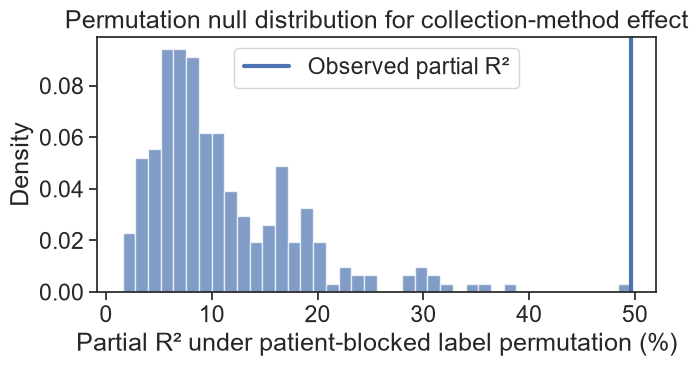

In [70]:
#observed_F = joint_test_result["F"]
observed_partial_R2 = joint_test_result["observed_partial_R2"]

plt.figure(figsize=(7, 4))

plt.hist(
    perm_R2 * 100,
    bins=40,
    alpha=0.7,
    density=True,
)

plt.axvline(
    observed_partial_R2 * 100,
    linewidth=3,
    label="Observed partial R²",
)

plt.xlabel("Partial R² under patient-blocked label permutation (%)")
plt.ylabel("Density")
plt.title("Permutation null distribution for collection-method effect")
plt.legend()
plt.tight_layout()
plt.savefig(f'Permutation_liver_phospho_{today}.pdf', bbox_inches='tight', dpi=300)
plt.show()

## 12. HCC PCA and paired distances

Repeat PCA, distance benchmarking, and patient-blocked permutation testing in tumor samples.

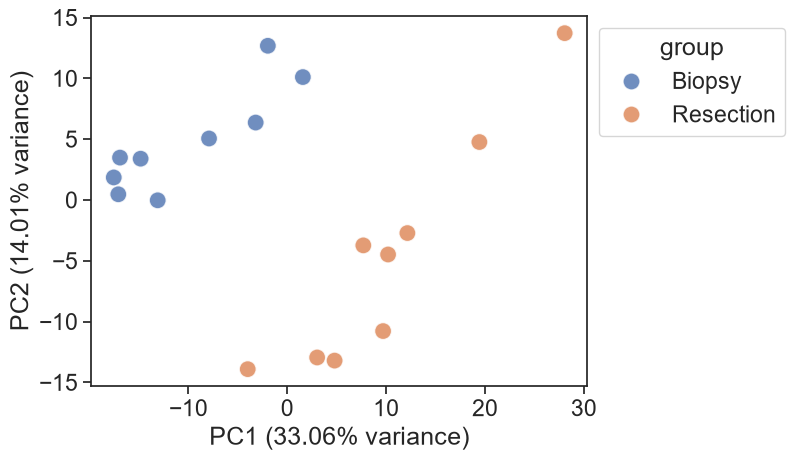

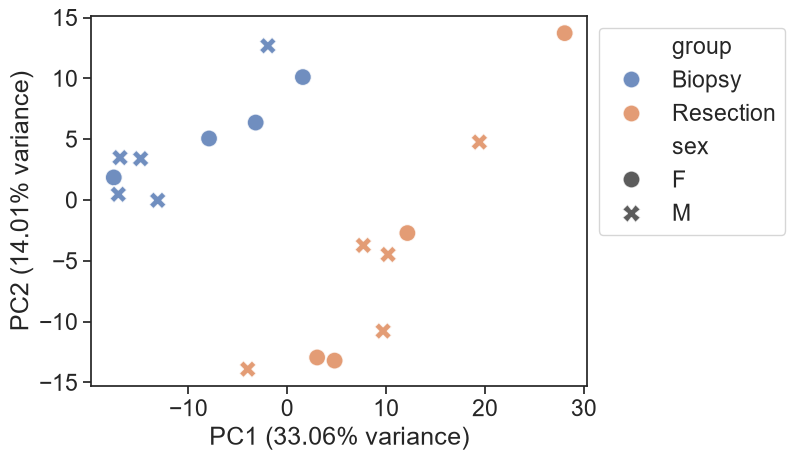

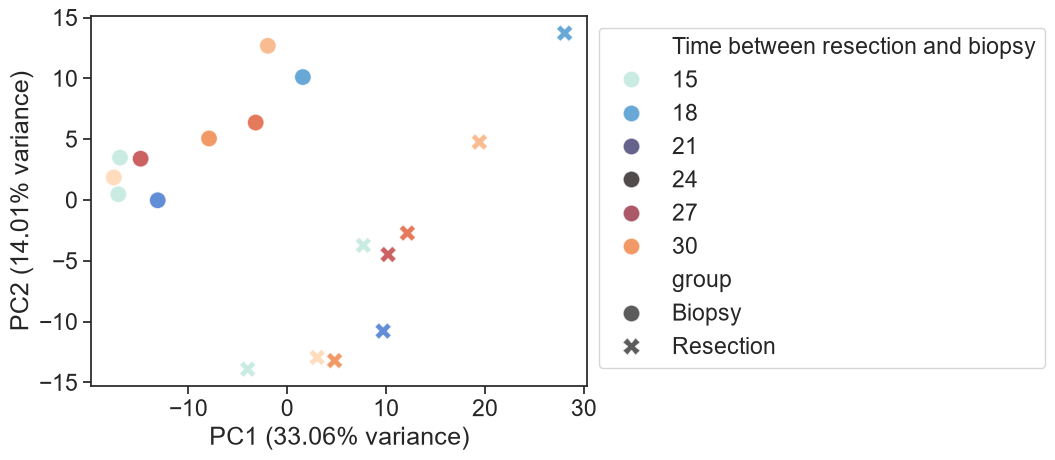

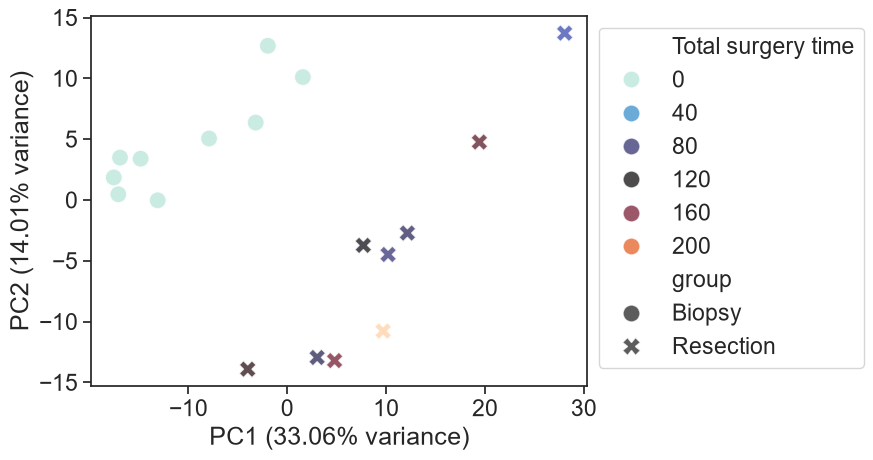

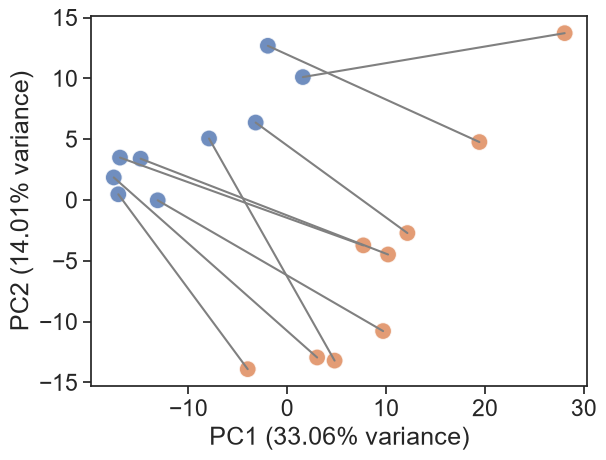

In [117]:
# HCC

# PCA
used_cols = [x for x in df_hcc_imputed.columns if x.startswith('tumor')]

# Most variable proteins
df_hcc_pca = df_hcc_imputed.loc[:,used_cols].copy()
df_hcc_pca['abs_std'] = df_hcc_pca.std(axis=1)
df_hcc_pca = df_hcc_pca.sort_values('abs_std', ascending=False)
df_hcc_pca = df_hcc_pca.iloc[:500,:-1]

scaled = scaler.fit_transform(df_hcc_pca.T)

pca_data = pca.fit_transform(scaled)

df_pca = pd.DataFrame(pca_data, index=used_cols, columns=[f'PC{x}' for x in range (1,11)])
df_pca['group'] = metadata_hcc.Sample_type
df_pca['sex'] = metadata_hcc.Sex
df_pca['patient_id'] = metadata_hcc.patient_id.astype(str)
df_pca['Time between resection and biopsy'] = metadata_hcc['Time between resection and biopsy']
df_pca['Total surgery time'] = metadata_hcc['Total surgery time']

# Overview
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_hcc_{today}.pdf', bbox_inches='tight', dpi=300)

#plt.show()

# Sex
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='sex',
                    hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_hcc_sex_{today}.pdf', bbox_inches='tight', dpi=300)

# Time between B and R
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='group',
                    hue='Time between resection and biopsy', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_hcc_timeBvR_{today}.pdf', bbox_inches='tight', dpi=300)

# Surgery time
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='group',
                    hue='Total surgery time', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_hcc_surgerytime_{today}.pdf', bbox_inches='tight', dpi=300)

# Patients
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
h = sns.lineplot(df_pca, x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
plt.legend([],[], frameon=False)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.savefig(f'figures/PCA_hcc_pat_{today}.pdf', bbox_inches='tight', dpi=300)

In [118]:
K = 10
pc_cols = [f"PC{i+1}" for i in range(K)]

# scores,
# meta,
# patient_col="Patient ID",
# sample_type_col="Sample_type",
# biopsy_label="Biopsy",
# resection_label="Resection",

paired_distances, patient_centroids = paired_distance_magnitude(
    scores=df_pca,
    meta=metadata_hcc,
    patient_col='patient_id',
    sample_type_col='Sample_type',
    biopsy_label='Biopsy',
    resection_label='Resection',
    pc_cols=pc_cols,
)

paired_distances

,patient_id,biopsy_sample,resection_sample,n_pcs,paired_distance,PC1_resection_minus_biopsy,PC2_resection_minus_biopsy,PC3_resection_minus_biopsy,PC4_resection_minus_biopsy,PC5_resection_minus_biopsy,PC6_resection_minus_biopsy,PC7_resection_minus_biopsy,PC8_resection_minus_biopsy,PC9_resection_minus_biopsy,PC10_resection_minus_biopsy
0,D,tumor_Biopsy_D,tumor_Resection_D,10,28.273287,15.347397,-9.086244,-12.008564,-10.051823,-7.032384,-2.125797,-8.928263,-0.838657,1.125894,-10.018648
1,E,tumor_Biopsy_E,tumor_Resection_E,10,29.717783,21.398427,-7.916053,-2.468355,-0.202290,6.728210,5.000796,-3.962622,-14.462046,-6.257673,-4.708287
2,I,tumor_Biopsy_I,tumor_Resection_I,10,26.201997,12.699485,-18.263897,-8.611290,3.993722,-3.728784,-7.236456,4.517269,-2.245108,0.838644,3.028860
3,L,tumor_Biopsy_L,tumor_Resection_L,10,33.914366,26.482426,3.610168,-2.161571,-6.316691,10.479562,-8.208108,-11.221224,-0.133227,-6.789569,6.483283
4,N,tumor_Biopsy_N,tumor_Resection_N,10,36.934130,24.612556,-7.218334,19.833171,-14.376633,-6.809830,0.335708,7.571850,0.784481,-0.012495,-1.330591
5,O,tumor_Biopsy_O,tumor_Resection_O,10,29.263471,25.031544,-7.878312,-3.714464,4.270572,-7.790175,6.077074,-1.966885,3.611649,4.018870,2.233401
6,Q,tumor_Biopsy_Q,tumor_Resection_Q,10,30.247222,20.573275,-14.803632,4.898726,0.961933,6.065730,11.533768,6.565308,-2.246604,4.502753,3.052592
7,T,tumor_Biopsy_T,tumor_Resection_T,10,32.503313,22.799998,-10.752145,-14.750115,0.535115,-2.000306,-9.786033,3.454913,7.222405,2.621041,5.694515
8,U,tumor_Biopsy_U,tumor_Resection_U,10,33.120592,13.088718,-14.379658,21.755720,13.526409,-1.410402,-0.812761,-7.440490,0.948177,-1.351201,-1.368923


In [119]:
between_patient_centroid_distances = pdist(
    patient_centroids.loc[:, pc_cols].values,
    metric="euclidean",
)

median_paired_distance = paired_distances["paired_distance"].median()
median_between_patient_distance = np.median(between_patient_centroid_distances)

magnitude_ratio = median_paired_distance / median_between_patient_distance

paired_distance_percentile = percentileofscore(
    between_patient_centroid_distances,
    median_paired_distance,
    kind="rank",
)

magnitude_summary = pd.DataFrame({
    "n_pairs": [paired_distances.shape[0]],
    "n_pcs": [K],
    "median_paired_distance": [median_paired_distance],
    "mean_paired_distance": [paired_distances["paired_distance"].mean()],
    "median_between_patient_centroid_distance": [median_between_patient_distance],
    "paired_to_between_patient_distance_ratio": [magnitude_ratio],
    "median_paired_distance_percentile_vs_between_patient": [paired_distance_percentile],
})

magnitude_summary

,n_pairs,n_pcs,median_paired_distance,mean_paired_distance,median_between_patient_centroid_distance,paired_to_between_patient_distance_ratio,median_paired_distance_percentile_vs_between_patient
0,9,10,30.247222,31.130685,18.333385,1.649844,97.222222


In [120]:
paired_distances["percentile_vs_between_patient_centroids"] = [
    percentileofscore(
        between_patient_centroid_distances,
        d,
        kind="rank",
    )
    for d in paired_distances["paired_distance"]
]

paired_distances["ratio_to_median_between_patient_distance"] = (
    paired_distances["paired_distance"] / median_between_patient_distance
)

paired_distances

,patient_id,biopsy_sample,resection_sample,n_pcs,paired_distance,PC1_resection_minus_biopsy,PC2_resection_minus_biopsy,PC3_resection_minus_biopsy,PC4_resection_minus_biopsy,PC5_resection_minus_biopsy,PC6_resection_minus_biopsy,PC7_resection_minus_biopsy,PC8_resection_minus_biopsy,PC9_resection_minus_biopsy,PC10_resection_minus_biopsy,percentile_vs_between_patient_centroids,ratio_to_median_between_patient_distance
0,D,tumor_Biopsy_D,tumor_Resection_D,10,28.273287,15.347397,-9.086244,-12.008564,-10.051823,-7.032384,-2.125797,-8.928263,-0.838657,1.125894,-10.018648,91.666667,1.542175
1,E,tumor_Biopsy_E,tumor_Resection_E,10,29.717783,21.398427,-7.916053,-2.468355,-0.202290,6.728210,5.000796,-3.962622,-14.462046,-6.257673,-4.708287,94.444444,1.620965
2,I,tumor_Biopsy_I,tumor_Resection_I,10,26.201997,12.699485,-18.263897,-8.611290,3.993722,-3.728784,-7.236456,4.517269,-2.245108,0.838644,3.028860,86.111111,1.429196
3,L,tumor_Biopsy_L,tumor_Resection_L,10,33.914366,26.482426,3.610168,-2.161571,-6.316691,10.479562,-8.208108,-11.221224,-0.133227,-6.789569,6.483283,100.000000,1.849869
4,N,tumor_Biopsy_N,tumor_Resection_N,10,36.934130,24.612556,-7.218334,19.833171,-14.376633,-6.809830,0.335708,7.571850,0.784481,-0.012495,-1.330591,100.000000,2.014583
5,O,tumor_Biopsy_O,tumor_Resection_O,10,29.263471,25.031544,-7.878312,-3.714464,4.270572,-7.790175,6.077074,-1.966885,3.611649,4.018870,2.233401,94.444444,1.596185
6,Q,tumor_Biopsy_Q,tumor_Resection_Q,10,30.247222,20.573275,-14.803632,4.898726,0.961933,6.065730,11.533768,6.565308,-2.246604,4.502753,3.052592,97.222222,1.649844
7,T,tumor_Biopsy_T,tumor_Resection_T,10,32.503313,22.799998,-10.752145,-14.750115,0.535115,-2.000306,-9.786033,3.454913,7.222405,2.621041,5.694515,97.222222,1.772903
8,U,tumor_Biopsy_U,tumor_Resection_U,10,33.120592,13.088718,-14.379658,21.755720,13.526409,-1.410402,-0.812761,-7.440490,0.948177,-1.351201,-1.368923,100.000000,1.806573


In [121]:
diff_cols = [f"{pc}_resection_minus_biopsy" for pc in pc_cols]

diff_matrix = paired_distances[diff_cols].values

mean_displacement_vector = diff_matrix.mean(axis=0)

mean_vector_length = np.linalg.norm(mean_displacement_vector)
mean_individual_distance = np.mean(
    np.linalg.norm(diff_matrix, axis=1)
)

directional_coherence = mean_vector_length / mean_individual_distance

direction_summary = pd.DataFrame({
    "n_pairs": [paired_distances.shape[0]],
    "n_pcs": [K],
    "mean_vector_length": [mean_vector_length],
    "mean_individual_paired_distance": [mean_individual_distance],
    "directional_coherence": [directional_coherence],
})

direction_summary

,n_pairs,n_pcs,mean_vector_length,mean_individual_paired_distance,directional_coherence
0,9,10,22.490176,31.130685,0.722444


In [122]:
patient_col = 'patient_id'
distance_col = 'paired_distance'

# Copy and sort patient-level distances
plot_df = paired_distances[[patient_col, distance_col]].copy()
plot_df = plot_df.sort_values(distance_col, ascending=True).reset_index(drop=True)

# Summary stats for paired distances
paired_median = plot_df[distance_col].median()
paired_q1 = plot_df[distance_col].quantile(0.25)
paired_q3 = plot_df[distance_col].quantile(0.75)

# Summary stats for between-patient centroid distances
between_median = np.median(between_patient_centroid_distances)
between_q1 = np.quantile(between_patient_centroid_distances, 0.25)
between_q3 = np.quantile(between_patient_centroid_distances, 0.75)

In [123]:
plot_df_norm = plot_df.copy()
plot_df_norm["relative_distance"] = plot_df_norm[distance_col] / between_median
plot_df_norm = plot_df_norm.sort_values("relative_distance", ascending=True).reset_index(drop=True)

In [124]:
plot_df_norm.mean(numeric_only=True)

paired_distance      31.130685
relative_distance     1.698033
dtype: float64

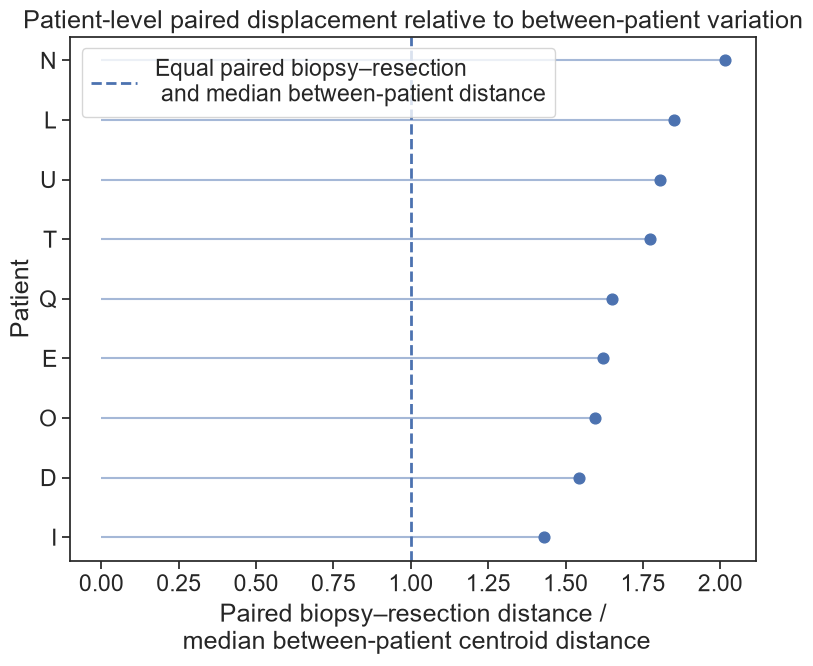

In [125]:
plt.figure(figsize=(8, 7))

y = np.arange(len(plot_df_norm))

# Summary stats for paired distances
paired_median = plot_df_norm[distance_col].median()

# Summary stats for between-patient centroid distances
between_median = np.median(between_patient_centroid_distances)

for yi, x in zip(y, plot_df_norm["relative_distance"]):
    plt.hlines(y=yi, xmin=0, xmax=x, linewidth=1.5, alpha=0.5)

plt.scatter(plot_df_norm["relative_distance"], y, s=60, zorder=3)

plt.axvline(1.0, linestyle="--", linewidth=2, label="Equal paired biopsy–resection \n and median between-patient distance")
#plt.axvline(0.5, linestyle=":", linewidth=1.5)
#plt.axvline(0.25, linestyle=":", linewidth=1.5)

# plt.axvline(
#     paired_median,
#     linewidth=1.5,
#     label="Median paired biopsy–resection distance"
# )

# plt.axvline(
#     between_median,
#     linewidth=1.5,
#     label="Median between-patient distance"
# )

plt.yticks(y, plot_df_norm[patient_col])
plt.xlabel("Paired biopsy–resection distance /\n median between-patient centroid distance")
plt.ylabel("Patient")
plt.title("Patient-level paired displacement relative to between-patient variation")
plt.legend()
plt.tight_layout()
plt.savefig(f'Distance_HCC_phospho_{today}.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [126]:
joint_test_result, perm_R2 = exhaustive_patient_blocked_collection_test(
    scores=df_pca,
    meta=metadata_hcc,
    patient_col='patient_id',
    sample_type_col='Sample_type',
    biopsy_label='Biopsy',
    resection_label='Resection',
    pc_cols=pc_cols,
)

joint_test_result

{'n_pairs': 9,
 'n_samples': 18,
 'n_pcs': 10,
 'observed_partial_R2': np.float64(0.5168297871501957),
 'observed_partial_R2_percent': np.float64(51.682978715019566),
 'exact_permutation_p_value': np.float64(0.00390625),
 'n_total_permutations': 512,
 'n_permutations_ge_observed': 2,
 'max_permuted_partial_R2': np.float64(0.5168297871501957),
 'max_permuted_partial_R2_percent': np.float64(51.682978715019566)}

In [127]:
test_out = pd.DataFrame().from_dict(joint_test_result, orient='index')
test_out.to_csv(f'Permutation_phosho_hcc_{today}.csv')
test_out

,0
n_pairs,9.000000
n_samples,18.000000
n_pcs,10.000000
observed_partial_R2,0.516830
observed_partial_R2_percent,51.682979
exact_permutation_p_value,0.003906
n_total_permutations,512.000000
n_permutations_ge_observed,2.000000
max_permuted_partial_R2,0.516830
max_permuted_partial_R2_percent,51.682979


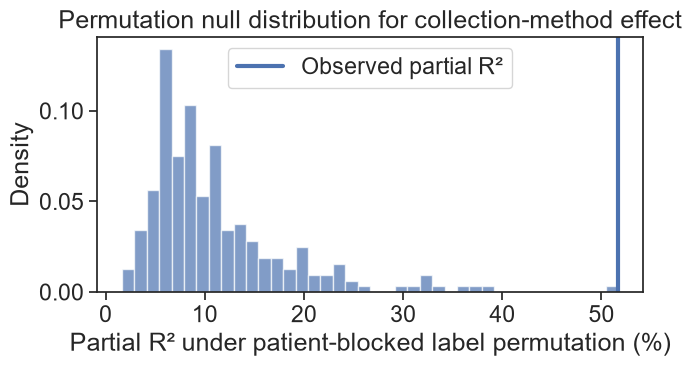

In [128]:
#observed_F = joint_test_result["F"]
observed_partial_R2 = joint_test_result["observed_partial_R2"]

plt.figure(figsize=(7, 4))

plt.hist(
    perm_R2 * 100,
    bins=40,
    alpha=0.7,
    density=True,
)

plt.axvline(
    observed_partial_R2 * 100,
    linewidth=3,
    label="Observed partial R²",
)

plt.xlabel("Partial R² under patient-blocked label permutation (%)")
plt.ylabel("Density")
plt.title("Permutation null distribution for collection-method effect")
plt.legend()
plt.tight_layout()
plt.savefig(f'Permutation_hcc_phospho_{today}.pdf', bbox_inches='tight', dpi=300)
plt.show()

## 13. Tumor-content sensitivity analysis

Test whether paired tumor-content changes are associated with HCC PCA displacement.

In [129]:
from scipy.stats import spearmanr

tumor_content_col = "tumor"  # change if needed
patient_col = "patient_id"
n_perm = 16384 #2**15
random_seed = 42

diff_cols = [
    f"{pc}_resection_minus_biopsy"
    for pc in pc_cols
]

# ------------------------------------------------------------------
# Assemble paired PCA and tumour-content changes
# ------------------------------------------------------------------

tumor_content = pd.to_numeric(
    metadata_hcc[tumor_content_col],
    errors="coerce",
)

analysis_df = paired_distances.copy()

analysis_df["biopsy_tumor_content"] = (
    analysis_df["biopsy_sample"].map(tumor_content)
)
analysis_df["resection_tumor_content"] = (
    analysis_df["resection_sample"].map(tumor_content)
)

# Signed change is needed for multivariate regression
analysis_df["tumor_content_delta"] = (
    analysis_df["resection_tumor_content"]
    - analysis_df["biopsy_tumor_content"]
)

# Absolute change is used for the magnitude correlation
analysis_df["tumor_content_change"] = (
    analysis_df["tumor_content_delta"].abs()
)

analysis_df["relative_pca_distance"] = (
    analysis_df["paired_distance"]
    / median_between_patient_distance
)

analysis_df = analysis_df.dropna(
    subset=[
        "tumor_content_delta",
        "relative_pca_distance",
        *diff_cols,
    ]
).copy()

if len(analysis_df) < 3:
    raise ValueError("At least three complete pairs are required.")

if analysis_df["tumor_content_delta"].nunique() < 2:
    raise ValueError("Tumour-content change has no variation.")

print(f"Complete pairs included: {len(analysis_df)}")

Complete pairs included: 8


In [130]:
spearman_rho, spearman_p = spearmanr(
    analysis_df["tumor_content_change"],
    analysis_df["relative_pca_distance"],
)

print(f"Spearman rho: {spearman_rho:.3f}")
print(f"Spearman p-value: {spearman_p:.4g}")

Spearman rho: -0.619
Spearman p-value: 0.1017


In [131]:
delta_tumor = analysis_df["tumor_content_delta"].to_numpy(dtype=float)
delta_pca = analysis_df[diff_cols].to_numpy(dtype=float)

# Multivariate OLS: one regression fitted jointly across all PC outcomes
X = np.column_stack([
    np.ones(len(delta_tumor)),
    delta_tumor,
])

coefficients, _, _, _ = np.linalg.lstsq(
    X,
    delta_pca,
    rcond=None,
)

sample_type_vector = coefficients[0]
tumor_content_slope = coefficients[1]

fitted_delta_pca = X @ coefficients
residual_delta_pca = delta_pca - fitted_delta_pca

# Multivariate R² across all included PCs
centered_delta_pca = delta_pca - delta_pca.mean(axis=0)

total_ss = np.sum(centered_delta_pca**2)
residual_ss = np.sum(residual_delta_pca**2)

multivariate_r2 = 1 - residual_ss / total_ss

# PCA-space effect sizes
sample_type_distance_adjusted = np.linalg.norm(
    sample_type_vector
)

tumor_distance_per_20_percent = np.linalg.norm(
    tumor_content_slope * 20
)

sample_type_relative_distance = (
    sample_type_distance_adjusted
    / median_between_patient_distance
)

tumor_relative_distance_per_20_percent = (
    tumor_distance_per_20_percent
    / median_between_patient_distance
)

In [132]:
def calculate_multivariate_r2(x, y):
    """R² for y ~ intercept + x, with multivariate y."""
    x_centered = x - x.mean()
    y_centered = y - y.mean(axis=0)

    x_ss = x_centered @ x_centered
    y_ss = np.sum(y_centered**2)

    slopes = (x_centered @ y_centered) / x_ss
    fitted_centered = np.outer(x_centered, slopes)

    return np.sum(fitted_centered**2) / y_ss


rng = np.random.default_rng(random_seed)
permuted_r2 = np.empty(n_perm)

for i in range(n_perm):
    permuted_delta = rng.permutation(delta_tumor)
    permuted_r2[i] = calculate_multivariate_r2(
        permuted_delta,
        delta_pca,
    )

multivariate_permutation_p = (
    1 + np.count_nonzero(permuted_r2 >= multivariate_r2)
) / (n_perm + 1)

In [133]:
multivariate_summary = pd.DataFrame({
    "n_pairs": [len(analysis_df)],
    "n_pcs": [len(pc_cols)],
    "multivariate_r_squared": [multivariate_r2],
    "permutation_p_value": [multivariate_permutation_p],
    "adjusted_sample_type_distance": [
        sample_type_distance_adjusted
    ],
    "adjusted_sample_type_relative_distance": [
        sample_type_relative_distance
    ],
    "tumor_content_distance_per_20_percentage_points": [
        tumor_distance_per_20_percent
    ],
    "tumor_content_relative_distance_per_20_percentage_points": [
        tumor_relative_distance_per_20_percent
    ],
})

coefficient_table = pd.DataFrame({
    "PC": pc_cols,
    "adjusted_biopsy_to_resection_effect": sample_type_vector,
    "effect_per_20_percentage_point_tumor_change":
        tumor_content_slope * 20,
})

display(multivariate_summary)
display(coefficient_table)

,n_pairs,n_pcs,multivariate_r_squared,permutation_p_value,adjusted_sample_type_distance,adjusted_sample_type_relative_distance,tumor_content_distance_per_20_percentage_points,tumor_content_relative_distance_per_20_percentage_points
0,8,10,0.226803,0.068111,25.158636,1.372285,10.050235,0.548193


,PC,adjusted_biopsy_to_resection_effect,effect_per_20_percentage_point_tumor_change
0,PC1,21.852838,-1.629530
1,PC2,-6.988527,-1.948324
2,PC3,9.059515,-9.097755
3,PC4,-2.467316,1.355721
4,PC5,-0.168544,-1.245824
5,PC6,-2.881692,0.768043
6,PC7,-1.284277,-0.939175
7,PC8,0.480920,-1.092644
8,PC9,-1.855603,1.102236
9,PC10,2.179907,-2.125079


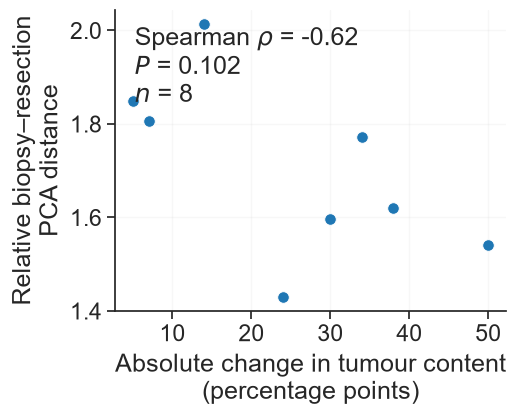

In [134]:
x = analysis_df["tumor_content_change"]
y = analysis_df["relative_pca_distance"]

rho, p_value = spearmanr(x, y)

fig, ax = plt.subplots(figsize=(5.5, 4.5))

ax.scatter(
    x,
    y,
    s=70,
    color="tab:blue",
    edgecolor="white",
    linewidth=0.7,
)

ax.text(
    0.05,
    0.95,
    (
        f"Spearman $\\rho$ = {rho:.2f}\n"
        f"$P$ = {p_value:.3f}\n"
        f"$n$ = {len(analysis_df)}"
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
)

ax.set_xlabel(
    "Absolute change in tumour content\n"
    "(percentage points)"
)
ax.set_ylabel(
    "Relative biopsy–resection\nPCA distance"
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.15)
fig.tight_layout()

fig.savefig(
    "Tumor_content_vs_PCA_distance_simple.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

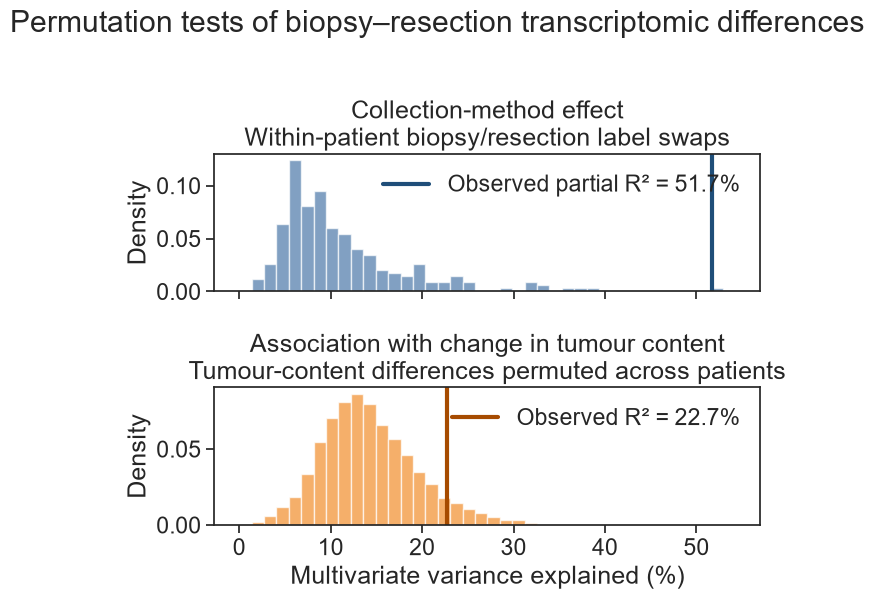

In [135]:
collection_null = perm_R2 * 100
tissue_null = permuted_r2 * 100

collection_observed = (
    joint_test_result["observed_partial_R2"] * 100
)
tissue_observed = multivariate_r2 * 100

# Common range and bin edges make visual comparison easier
x_max = max(
    collection_null.max(),
    tissue_null.max(),
    collection_observed,
    tissue_observed,
)

bins = np.linspace(0, x_max * 1.05, 41)

fig, axes = plt.subplots(
    2, 1,
    figsize=(7, 6),
    sharex=True,
)

# Collection-method test
axes[0].hist(
    collection_null,
    bins=bins,
    density=True,
    alpha=0.7,
    color="#4C78A8",
)

axes[0].axvline(
    collection_observed,
    color="#1F4E79",
    linewidth=3,
    label=f"Observed partial R² = {collection_observed:.1f}%",
)

axes[0].set_ylabel("Density")
axes[0].set_title(
    "Collection-method effect\n"
    "Within-patient biopsy/resection label swaps"
)
axes[0].legend(frameon=False)

# Tissue-composition test
axes[1].hist(
    tissue_null,
    bins=bins,
    density=True,
    alpha=0.7,
    color="#F28E2B",
)

axes[1].axvline(
    tissue_observed,
    color="#A64B00",
    linewidth=3,
    label=f"Observed R² = {tissue_observed:.1f}%",
)

axes[1].set_xlabel("Multivariate variance explained (%)")
axes[1].set_ylabel("Density")
axes[1].set_title(
    "Association with change in tumour content\n"
    "Tumour-content differences permuted across patients"
)
axes[1].legend(frameon=False)

fig.suptitle(
    "Permutation tests of biopsy–resection phospho-proteomic differences",
    y=1.01,
)

plt.tight_layout()
plt.savefig(
    "Permutation_histograms_collection_and_tissue_composition.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

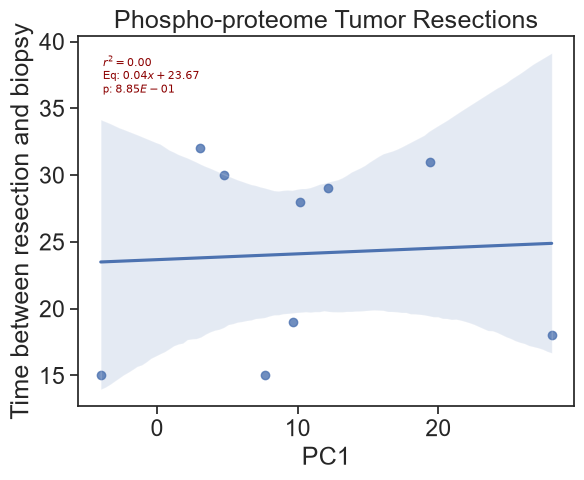

In [136]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Time between resection and biopsy')
r2(df_pca_biop.PC1, df_pca_biop['Time between resection and biopsy'])

plt.title('Phospho-proteome Tumor Resections')


plt.savefig(f'figures/corr_pc1_time_b_to_r_tumor_{today}.pdf', dpi=300, bbox_inches='tight')

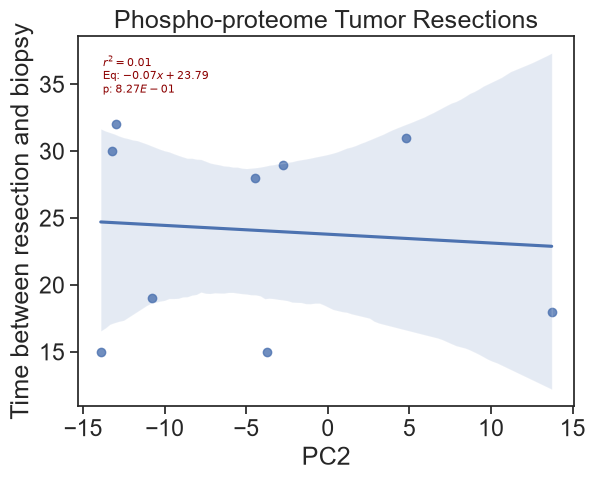

In [137]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Time between resection and biopsy')
r2(df_pca_biop.PC2, df_pca_biop['Time between resection and biopsy'])

plt.title('Phospho-proteome Tumor Resections')


plt.savefig(f'figures/corr_pc2_time_b_to_r_tumor_{today}.pdf', dpi=300, bbox_inches='tight')

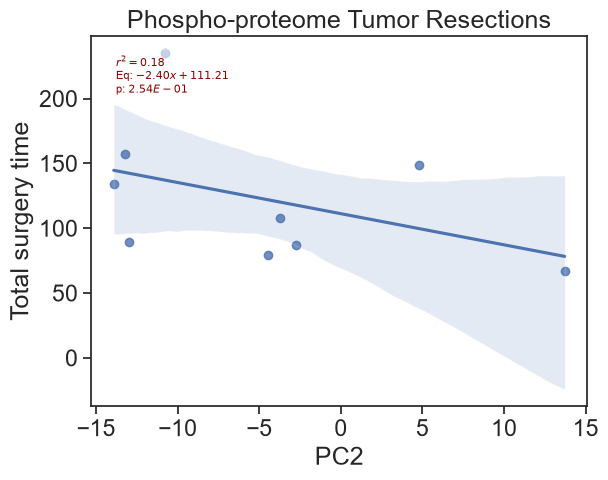

In [89]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Total surgery time')
r2(df_pca_biop.PC2, df_pca_biop['Total surgery time'])

plt.title('Phospho-proteome Tumor Resections')

plt.savefig(f'figures/corr_pc2_time_surgery_tumor_{today}.pdf', dpi=300, bbox_inches='tight')

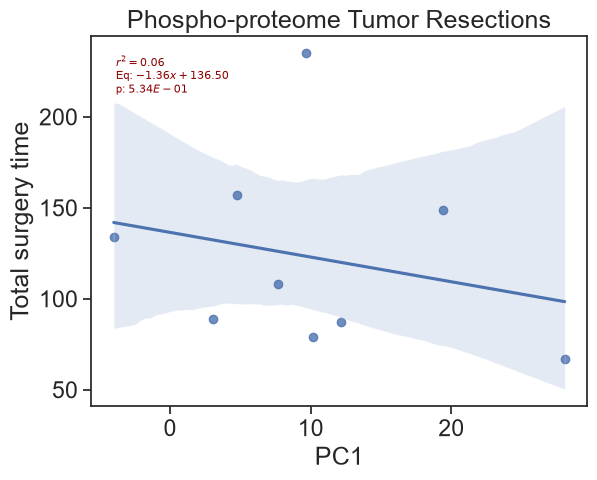

In [90]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Total surgery time')
r2(df_pca_biop.PC1, df_pca_biop['Total surgery time'])

plt.title('Phospho-proteome Tumor Resections')

plt.savefig(f'figures/corr_pc1_time_surgery_tumor_{today}.pdf', dpi=300, bbox_inches='tight')

## 14. Paired t-test helper functions

Define paired testing, multiple-testing, fold-change, and plotting utilities.

In [91]:
# Helper functions for calculating p-values, adjusted p-values and fold-changes
from scipy import stats

def students_ttest(df, group_cols, control_cols, index_col=None,
                   group_name="group", control_name="control",
                   paired=False, pairing=None):
    """
    Perform Student's t-test (paired or unpaired) between two groups of samples.

    Parameters:
    - df : pandas.DataFrame
        Features as rows, samples as columns.
    - group_cols : list of str
        Column names of the treatment group.
    - control_cols : list of str
        Column names of the control group.
    - index_col : str or None
        If provided, column to set as index in the result.
    - group_name : str
        Label for the group (used in output column names).
    - control_name : str
        Label for the control (used in output column names).
    - paired : bool
        If True, perform paired t-test (requires `pairing`).
    - pairing : pd.Series or None
        Required if `paired=True`. Index = sample names (columns), values = pairing IDs.

    Returns:
    - df_result : pandas.DataFrame
        Contains t-statistics, p-values, adjusted p-values, and fold changes.
    """
    df_ = df.copy()

    if paired:
        if pairing is None:
            raise ValueError("Pairing metadata must be provided for paired t-test.")
        # Map pair IDs to columns for each group
        group_pairs = pairing.loc[group_cols]
        control_pairs = pairing.loc[control_cols]

        # Find common pair IDs between group and control
        common_pairs = group_pairs[group_pairs.isin(control_pairs.values)].unique()
        if len(common_pairs) == 0:
            raise ValueError("No matching pair IDs found between group and control.")

        # Align columns based on common pair IDs
        group_aligned = [col for col in group_cols if pairing[col] in common_pairs]
        control_aligned = [col for col in control_cols if pairing[col] in common_pairs]
        
        # Map from pair ID to column
        group_map = {pairing[col]: col for col in group_aligned}
        control_map = {pairing[col]: col for col in control_aligned}
        shared_pairs = sorted(set(group_map.keys()) & set(control_map.keys()))

        group_cols_final = [group_map[p] for p in shared_pairs]
        control_cols_final = [control_map[p] for p in shared_pairs]

        if len(group_cols_final) != len(control_cols_final):
            raise ValueError("Aligned paired samples are not the same length.")

        # Paired t-test
        tstats, pvals = stats.ttest_rel(
            df_[group_cols_final].values,
            df_[control_cols_final].values,
            axis=1,
            nan_policy='propagate'
        )
        fold_change = df_[group_cols_final].mean(axis=1) - df_[control_cols_final].mean(axis=1)
    else:
        # Unpaired t-test
        ttest_result = stats.ttest_ind(
            df_[group_cols],
            df_[control_cols],
            axis=1,
            nan_policy='propagate'
        )
        tstats = ttest_result.statistic
        pvals = ttest_result.pvalue
        fold_change = df_[group_cols].mean(axis=1) - df_[control_cols].mean(axis=1)

    label = f"{group_name}vs{control_name}"
    stats_col = f"{label}_tstat"
    pval_col = f"{label}_pval"
    adj_pval_col = f"{label}_adj_pval"
    fc_col = f"{label}_fc"

    # Build result table
    df_[stats_col] = tstats
    df_[pval_col] = pvals
    df_[fc_col] = fold_change

    # Multiple testing correction (Benjamini-Hochberg)
    df_ = df_.sort_values(pval_col).reset_index(names='ID')
    n = df_.shape[0]
    ranks = np.arange(1, n + 1)
    bh_adj = df_[pval_col] * n / ranks
    df_[adj_pval_col] = np.minimum.accumulate(bh_adj[::-1])[::-1].clip(upper=1.0)


    df_.index = df_.ID  # preserve original

    return df_


def power_to_transform(x):
    return 10 ** -x
def neg_log10(x):
    return np.log10(1/x)

## 15. Non-tumor differential phosphorylation

Run the retained paired t-test workflow and export the non-tumor results.

In [92]:
res = students_ttest(
    df=df_liver_imputed,
    group_cols=metadata_liver[metadata_liver.Sample_type == 'Resection'].index,
    control_cols=metadata_liver[metadata_liver.Sample_type == 'Biopsy'].index,
    group_name="Resection",
    control_name="Biopsy",
    paired=True,
    pairing=metadata_liver.patient_id,
)


In [93]:
res['-log10 pval'] = -np.log10(res['ResectionvsBiopsy_pval'])

In [94]:
res = res.rename({'ID':'Gene'}, axis=1)
res.head()

,Gene,non-tumor_Biopsy_D,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_I,non-tumor_Biopsy_T,non-tumor_Biopsy_U,non-tumor_Biopsy_L,non-tumor_Biopsy_E,missingindicator_non-tumor_Biopsy_D,missingindicator_non-tumor_Biopsy_N,missingindicator_non-tumor_Biopsy_O,missingindicator_non-tumor_Biopsy_Q,missingindicator_non-tumor_Biopsy_I,missingindicator_non-tumor_Biopsy_T,missingindicator_non-tumor_Biopsy_U,missingindicator_non-tumor_Biopsy_L,missingindicator_non-tumor_Biopsy_E,non-tumor_Resection_D,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,non-tumor_Resection_I,non-tumor_Resection_U,non-tumor_Resection_L,non-tumor_Resection_E,missingindicator_non-tumor_Resection_D,missingindicator_non-tumor_Resection_N,missingindicator_non-tumor_Resection_O,missingindicator_non-tumor_Resection_Q,missingindicator_non-tumor_Resection_T,missingindicator_non-tumor_Resection_I,missingindicator_non-tumor_Resection_U,missingindicator_non-tumor_Resection_L,missingindicator_non-tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval,-log10 pval
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
PDXDC1_S786,PDXDC1_S786,17.436205,17.072623,16.814290,17.134813,16.927297,17.071043,15.417414,17.500439,16.577237,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,21.927024,20.740999,20.298884,21.832422,21.370625,23.469337,20.916200,21.034818,21.321752,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,13.706719,7.736257e-07,4.551189,0.002866,6.111469
CRTC2_S613,CRTC2_S613,18.443757,17.303656,19.647304,16.684105,17.230321,17.559048,15.443562,16.387825,17.919684,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.136110,20.810537,21.456560,20.497565,20.154398,20.587626,19.865688,19.771446,21.089666,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.664916,1.419949e-06,3.194482,0.002866,5.847727
STBD1_S211,STBD1_S211,18.835196,18.711680,18.124412,17.521217,19.829014,19.051907,16.369861,18.874078,19.014593,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,21.256886,21.736985,22.822190,20.622325,22.027479,21.831807,19.319502,23.037594,22.844921,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.471713,3.019118e-06,3.240859,0.003242,5.520120
STIM1_S257,STIM1_S257,17.859310,17.714091,20.427785,17.020217,19.582209,19.183960,17.326930,17.902808,19.105553,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,22.590568,22.885292,24.125719,22.589247,22.810037,22.032805,23.926809,23.255472,23.274635,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,11.068512,3.958705e-06,4.596413,0.003242,5.402447
TAGLN2_S163,TAGLN2_S163,18.790224,18.063211,21.077546,17.669612,19.938954,19.081933,17.828487,19.590099,18.797734,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,24.678069,24.752564,24.859076,20.440119,24.695740,23.794615,24.492442,24.228899,24.983062,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.877473,4.514887e-06,5.120754,0.003242,5.345353


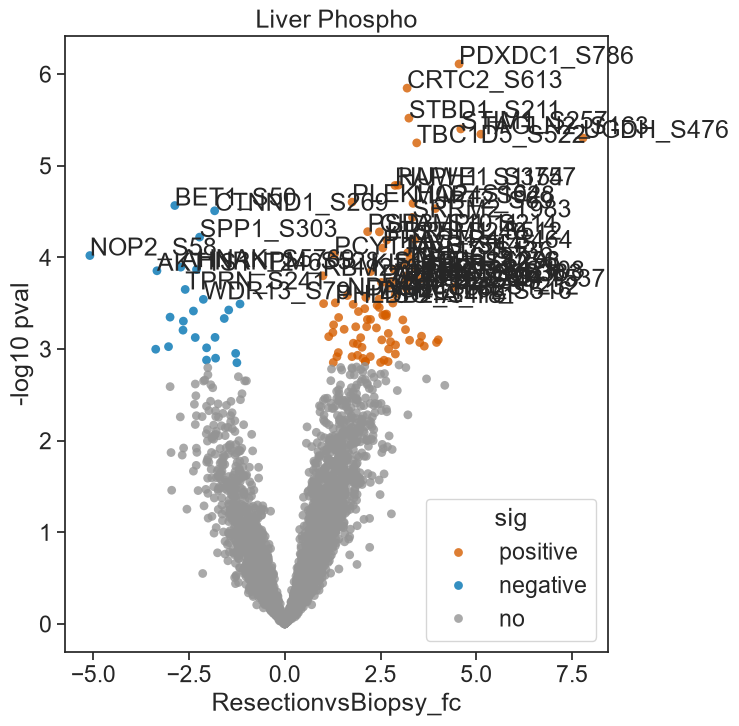

In [96]:
df_ttest_ = res.copy()

df_ttest_['sig'] = np.where((df_ttest_['ResectionvsBiopsy_adj_pval'] < 0.05) &\
                            (df_ttest_['ResectionvsBiopsy_fc'] > 0), 'positive',
                    np.where((df_ttest_['ResectionvsBiopsy_adj_pval'] < 0.05) &\
                             (df_ttest_['ResectionvsBiopsy_fc'] < 0), 'negative', 
                                    'no'))

fig, ax = plt.subplots(figsize=(7,8))

colors = sns.color_palette('colorblind')

sns.scatterplot(data=df_ttest_, x='ResectionvsBiopsy_fc', y='-log10 pval',
                hue='sig', alpha=0.8, linewidth=0, palette=[colors[3], colors[0], colors[7]],
                hue_order=['positive', 'negative', 'no'], s=40)

most_sig = df_ttest_.sort_values('-log10 pval', ascending=False)
                

for i in range(0,50):
    x = most_sig.iloc[i,:]['ResectionvsBiopsy_fc'].item()
    y = most_sig.iloc[i,:]['-log10 pval'].item()
    label = most_sig.iloc[i,:]['Gene'] 
    plt.text(x=x, y=y, s=label)
    
plt.title('Liver Phospho')
#plt.show()
plt.savefig(f'Volcano_proteomics_liver_output_{today}.pdf', bbox_inches='tight', dpi=300)

In [97]:
df_ttest_.to_csv(f'phospho_ttest_Liver_{today}.csv')

In [98]:
df_ttest_liver = df_ttest_.copy()
df_liver_sig = most_sig[most_sig.sig != 'no'].copy()
df_liver_sig.shape

(116, 43)

## 16. HCC differential phosphorylation

Repeat paired testing and plotting in HCC.

In [99]:
# HCC

res = students_ttest(
    df=df_hcc_imputed,
    group_cols=metadata_hcc[metadata_hcc.Sample_type == 'Resection'].index,
    control_cols=metadata_hcc[metadata_hcc.Sample_type == 'Biopsy'].index,
    group_name="Resection",
    control_name="Biopsy",
    paired=True,
    pairing=metadata_hcc.patient_id,
)

In [100]:
res['-log10 pval'] = -np.log10(res['ResectionvsBiopsy_pval'])

In [101]:
res = res.rename({'ID':'Gene'}, axis=1)
res.head()

,Gene,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_U,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_U,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_U,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_U,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval,-log10 pval
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
PNN_S66,PNN_S66,19.498979,18.594295,18.465076,18.947996,18.625263,18.133743,18.407865,18.930763,18.460992,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,21.843022,22.125993,22.057054,22.155844,22.233706,22.248065,21.498998,22.473703,22.938509,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,17.353622,1.239072e-07,3.501102,0.000295,6.906903
SMAP2_S240,SMAP2_S240,17.852734,19.124457,18.581838,18.366062,18.056912,17.955849,18.615177,18.998259,19.860725,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,22.096117,21.523777,22.572814,21.782028,21.933258,21.862109,21.269123,22.441644,23.838892,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,16.655049,1.707606e-07,3.545305,0.000295,6.767612
TRIM28_S473,TRIM28_S473,14.892991,12.999058,16.150508,15.538352,15.001914,15.404143,15.834649,17.919473,16.385241,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,21.511169,20.898973,20.903541,20.324260,22.394226,20.504371,20.736044,22.660725,22.773996,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,14.969296,3.915130e-07,5.842331,0.000376,6.407254
RBM7_S136,RBM7_S136,16.099812,15.556002,14.760091,14.670546,16.333659,17.840039,15.055999,18.200845,16.743085,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,20.634563,19.796011,20.356813,19.899737,21.080581,19.909761,18.910833,21.539304,20.180868,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,14.487317,5.044405e-07,4.116488,0.000376,6.297190
FGA_S594,FGA_S594,16.902937,16.223951,17.163045,17.224999,16.553806,16.921410,16.553383,17.770440,17.421999,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,19.288422,18.928087,19.122987,18.950564,18.690124,18.545220,19.195675,19.273480,19.150659,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,14.221699,5.820195e-07,2.045472,0.000376,6.235062


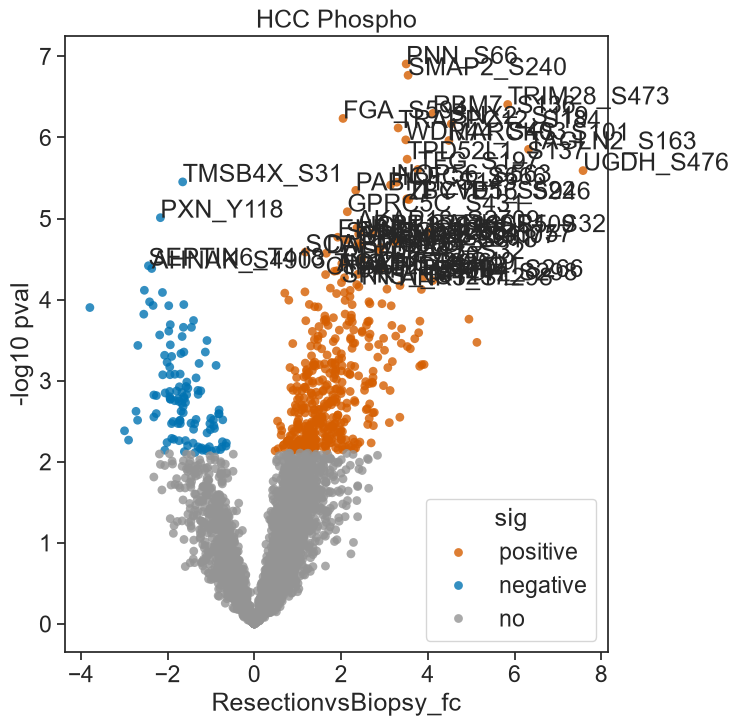

In [102]:
df_ttest_ = res.copy()

df_ttest_['sig'] = np.where((df_ttest_['ResectionvsBiopsy_adj_pval'] < 0.05) &\
                            (df_ttest_['ResectionvsBiopsy_fc'] > 0), 'positive',
                    np.where((df_ttest_['ResectionvsBiopsy_adj_pval'] < 0.05) &\
                             (df_ttest_['ResectionvsBiopsy_fc'] < 0), 'negative', 
                                    'no'))

fig, ax = plt.subplots(figsize=(7,8))

colors = sns.color_palette('colorblind')

sns.scatterplot(data=df_ttest_, x='ResectionvsBiopsy_fc', y='-log10 pval',
                hue='sig', alpha=0.8, linewidth=0, palette=[colors[3], colors[0], colors[7]],
                hue_order=['positive', 'negative', 'no'], s=40)

most_sig = df_ttest_.sort_values('-log10 pval', ascending=False)

for i in range(0,50):
    x = most_sig.iloc[i,:]['ResectionvsBiopsy_fc'].item()
    y = most_sig.iloc[i,:]['-log10 pval'].item()
    label = most_sig.iloc[i,:]['Gene'] 
    plt.text(x=x, y=y, s=label)
    
plt.title('HCC Phospho')
#plt.show()
plt.savefig(f'Volcano_proteomics_hcc_output_{today}.pdf', bbox_inches='tight', dpi=300)

In [103]:
df_ttest_.to_csv(f'phospho_ttest_hcc_{today}.csv')

In [104]:
df_ttest_hcc = df_ttest_.copy()
df_hcc_sig = most_sig[most_sig.sig != 'no'].copy()
df_hcc_sig.shape

(536, 43)

## 17. Consolidated phosphoproteomics export

Combine imputed intensities, paired t-test statistics, and limma results.

In [107]:
df_liver_imputed.shape

(4037, 36)

In [108]:
df_hcc_imputed.shape

(3457, 36)

In [109]:
merged_imputed = pd.concat([df_liver_imputed, df_hcc_imputed], axis=1)
merged_imputed.isna().sum()

non-tumor_Biopsy_D                    299
non-tumor_Biopsy_N                    299
non-tumor_Biopsy_O                    299
non-tumor_Biopsy_Q                    299
non-tumor_Biopsy_I                    299
                                     ... 
missingindicator_tumor_Resection_T    879
missingindicator_tumor_Resection_I    879
missingindicator_tumor_Resection_U    879
missingindicator_tumor_Resection_L    879
missingindicator_tumor_Resection_E    879
Length: 72, dtype: int64

In [110]:
merged_imputed.head()

,non-tumor_Biopsy_D,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_I,non-tumor_Biopsy_T,non-tumor_Biopsy_U,non-tumor_Biopsy_L,non-tumor_Biopsy_E,missingindicator_non-tumor_Biopsy_D,missingindicator_non-tumor_Biopsy_N,missingindicator_non-tumor_Biopsy_O,missingindicator_non-tumor_Biopsy_Q,missingindicator_non-tumor_Biopsy_I,missingindicator_non-tumor_Biopsy_T,missingindicator_non-tumor_Biopsy_U,missingindicator_non-tumor_Biopsy_L,missingindicator_non-tumor_Biopsy_E,non-tumor_Resection_D,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,non-tumor_Resection_I,non-tumor_Resection_U,non-tumor_Resection_L,non-tumor_Resection_E,missingindicator_non-tumor_Resection_D,missingindicator_non-tumor_Resection_N,missingindicator_non-tumor_Resection_O,missingindicator_non-tumor_Resection_Q,missingindicator_non-tumor_Resection_T,missingindicator_non-tumor_Resection_I,missingindicator_non-tumor_Resection_U,missingindicator_non-tumor_Resection_L,missingindicator_non-tumor_Resection_E,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_U,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_U,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_U,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_U,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E
site_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
RAMACL_S36,16.509716,15.717055,16.310645,14.741859,15.899265,18.487966,15.916383,17.751971,18.128296,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,17.071890,17.046112,17.620327,17.357182,16.992686,16.230182,18.437533,18.715151,18.943728,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MED19_S226,17.352328,16.886506,19.404666,15.717528,18.324338,19.229237,16.571335,15.548003,16.529609,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,17.624767,19.392032,20.014285,18.844402,17.757924,18.690680,19.244447,19.624467,19.006479,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.763750,18.975840,16.550287,18.881260,18.441000,19.967745,17.878919,17.406886,17.089140,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,18.640637,18.638135,18.756517,14.921822,19.075252,17.928998,19.131143,15.442098,18.225283,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
SHTN1_S101,18.432868,16.411163,17.863588,16.491135,17.994642,20.195391,17.068072,18.985272,19.988762,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,17.697520,19.279054,18.125899,18.097821,16.754131,17.329697,18.398872,17.587029,18.022482,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SHTN1_S249,21.489420,20.793206,19.941890,20.029853,17.140251,19.223745,16.802441,21.182166,22.163664,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.467086,17.788183,18.141464,17.107227,16.910572,18.890220,16.892027,19.178273,19.958581,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,20.880080,20.378555,19.949248,19.831180,20.852517,17.740947,19.077481,20.790886,20.915844,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.550085,16.925584,19.847279,18.973622,18.533417,16.671652,15.722373,21.078608,17.639666,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SHTN1_S506,19.994422,19.642360,18.599601,18.296836,18.887375,19.364325,15.833952,21.290370,20.906098,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.

In [111]:
merge_limma = liver_limma['results'].merge(hcc_limma['results'], right_index=True, left_index=True, suffixes=('_limma_non-tumor', '_limma_tumor'))

In [112]:
merged = df_ttest_liver.loc[:,'ResectionvsBiopsy_tstat':].merge(df_ttest_hcc.loc[:,'ResectionvsBiopsy_tstat':], right_index=True, left_index=True, suffixes=('_knn_non-tumor', '_knn_tumor'))
merged.head()

,ResectionvsBiopsy_tstat_knn_non-tumor,ResectionvsBiopsy_pval_knn_non-tumor,ResectionvsBiopsy_fc_knn_non-tumor,ResectionvsBiopsy_adj_pval_knn_non-tumor,-log10 pval_knn_non-tumor,sig_knn_non-tumor,ResectionvsBiopsy_tstat_knn_tumor,ResectionvsBiopsy_pval_knn_tumor,ResectionvsBiopsy_fc_knn_tumor,ResectionvsBiopsy_adj_pval_knn_tumor,-log10 pval_knn_tumor,sig_knn_tumor
ID,,,,,,,,,,,,
CRTC2_S613,12.664916,0.000001,3.194482,0.002866,5.847727,positive,7.497862,0.000069,2.410318,0.004705,4.158529,positive
STBD1_S211,11.471713,0.000003,3.240859,0.003242,5.520120,positive,4.218394,0.002922,2.648242,0.029888,2.534288,positive
TAGLN2_S163,10.877473,0.000005,5.120754,0.003242,5.345353,positive,12.688483,0.000001,6.322689,0.000484,5.853911,positive
UGDH_S476,10.738990,0.000005,7.789118,0.003242,5.303407,positive,11.723085,0.000003,7.579374,0.000681,5.591620,positive
TBC1D5_S522,10.565409,0.000006,3.445649,0.003242,5.250150,positive,10.542805,0.000006,3.516448,0.001060,5.243159,positive


In [113]:
proteome_export = pd.concat([merged, merge_limma, merged_imputed], axis=1)

In [114]:
proteome_export = proteome_export.loc[:,sorted(proteome_export.columns.tolist())]

In [115]:
proteome_export.to_csv(f"phospho_export_{today}.csv")

In [116]:
proteome_export.head()

,-log10 pval_knn_non-tumor,-log10 pval_knn_tumor,AveExpr_limma_non-tumor,AveExpr_limma_tumor,B_limma_non-tumor,B_limma_tumor,ResectionvsBiopsy_adj_pval_knn_non-tumor,ResectionvsBiopsy_adj_pval_knn_tumor,ResectionvsBiopsy_fc_knn_non-tumor,ResectionvsBiopsy_fc_knn_tumor,ResectionvsBiopsy_pval_knn_non-tumor,ResectionvsBiopsy_pval_knn_tumor,ResectionvsBiopsy_tstat_knn_non-tumor,ResectionvsBiopsy_tstat_knn_tumor,adj_pvalue_limma_non-tumor,adj_pvalue_limma_tumor,effect_limma_non-tumor,effect_limma_tumor,incomplete_pair_fraction_limma_non-tumor,incomplete_pair_fraction_limma_tumor,lfcSE_limma_non-tumor,lfcSE_limma_tumor,log2FoldChange_limma_non-tumor,log2FoldChange_limma_tumor,mean_log2_intensity_limma_non-tumor,mean_log2_intensity_limma_tumor,missingindicator_non-tumor_Biopsy_D,missingindicator_non-tumor_Biopsy_E,missingindicator_non-tumor_Biopsy_I,missingindicator_non-tumor_Biopsy_L,missingindicator_non-tumor_Biopsy_N,missingindicator_non-tumor_Biopsy_O,missingindicator_non-tumor_Biopsy_Q,missingindicator_non-tumor_Biopsy_T,missingindicator_non-tumor_Biopsy_U,missingindicator_non-tumor_Resection_D,missingindicator_non-tumor_Resection_E,missingindicator_non-tumor_Resection_I,missingindicator_non-tumor_Resection_L,missingindicator_non-tumor_Resection_N,missingindicator_non-tumor_Resection_O,missingindicator_non-tumor_Resection_Q,missingindicator_non-tumor_Resection_T,missingindicator_non-tumor_Resection_U,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_E,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_U,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_E,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_U,n_complete_pairs_limma_non-tumor,n_complete_pairs_limma_tumor,n_incomplete_pairs_limma_non-tumor,n_incomplete_pairs_limma_tumor,n_raw_missing_values_limma_non-tumor,n_raw_missing_values_limma_tumor,n_raw_observed_values_limma_non-tumor,n_raw_observed_values_limma_tumor,non-tumor_Biopsy_D,non-tumor_Biopsy_E,non-tumor_Biopsy_I,non-tumor_Biopsy_L,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_T,non-tumor_Biopsy_U,non-tumor_Resection_D,non-tumor_Resection_E,non-tumor_Resection_I,non-tumor_Resection_L,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,non-tumor_Resection_U,pvalue_limma_non-tumor,pvalue_limma_tumor,raw_missing_fraction_limma_non-tumor,raw_missing_fraction_limma_tumor,sig_knn_non-tumor,sig_knn_tumor,significant_FDR_0.05_limma_non-tumor,significant_FDR_0.05_limma_tumor,stat_limma_non-tumor,stat_limma_tumor,tumor_Biopsy_D,tumor_Biopsy_E,tumor_Biopsy_I,tumor_Biopsy_L,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_T,tumor_Biopsy_U,tumor_Resection_D,tumor_Resection_E,tumor_Resection_I,tumor_Resection_L,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_U
CRTC2_S613,5.847727,4.158529,3.194482,2.377946,8.743927,1.182520,0.002866,0.004705,3.194482,2.410318,0.000001,0.000069,12.664916,7.497862,2.045880e-05,0.015165,Resection - Biopsy,Resection - Biopsy,0.000000,0.333333,0.333333,0.408248,3.194482,2.377946,18.999381,17.996140,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,6.0,0.0,3.0,0.0,3.0,18.0,15.0,18.443757,17.919684,17.230321,16.387825,17.303656,19.647304,16.684105,17.559048,15.443562,21.136110,21.089666,20.587626,19.771446,20.810537,21.456560,20.497565,20.154398,19.865688,3.997811e-08,3.051729e-04,0.000000,0.166667,positive,positive,True,True,7.402484,5.109847,18.350612,16.992783,17.528111,17.717293,15.675130,16.767900,16.1780

## 18. PTMsigDB input generation

Map phosphosites back to proteins and create GCT-format inputs for downstream PTM signature analysis.

In [128]:
def gct_format(df, title, p_val, fc_col):
    # Turn p val into log10 and negative for negative fold change sites (input for PTMsigDB)
    df_ = df.copy()
    df_ = df_.apply(lambda x: abs(np.log10(x)) if x.name in p_val else x)
    df_[p_val] = np.where((df_[fc_col] > 0), df_[p_val], (df_[p_val] - 2*(df_[p_val].abs())))
    df_ = df_.loc[:,['id.uniprot', p_val]]

    # Write GCT format file descriptives
    with open(f'gct_files/{title}.gct', 'w') as f:
        f.write('#1.2 \n')
        f.write(f'{len(df)}\t1 \n')
    # Dump dataframe to GCT file
    df_.to_csv(f'gct_files/{title}.gct', mode='a', sep='\t',index=False)

In [129]:
df_liver_sig

,Gene,non-tumor_Biopsy_D,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_I,non-tumor_Biopsy_T,non-tumor_Biopsy_U,non-tumor_Biopsy_L,non-tumor_Biopsy_E,missingindicator_non-tumor_Biopsy_D,missingindicator_non-tumor_Biopsy_N,missingindicator_non-tumor_Biopsy_O,missingindicator_non-tumor_Biopsy_Q,missingindicator_non-tumor_Biopsy_I,missingindicator_non-tumor_Biopsy_T,missingindicator_non-tumor_Biopsy_U,missingindicator_non-tumor_Biopsy_L,missingindicator_non-tumor_Biopsy_E,non-tumor_Resection_D,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,non-tumor_Resection_I,non-tumor_Resection_U,non-tumor_Resection_L,non-tumor_Resection_E,missingindicator_non-tumor_Resection_D,missingindicator_non-tumor_Resection_N,missingindicator_non-tumor_Resection_O,missingindicator_non-tumor_Resection_Q,missingindicator_non-tumor_Resection_T,missingindicator_non-tumor_Resection_I,missingindicator_non-tumor_Resection_U,missingindicator_non-tumor_Resection_L,missingindicator_non-tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval,-log10 pval,sig
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
PDXDC1_S786,PDXDC1_S786,17.436205,17.072623,16.814290,17.134813,16.927297,17.071043,15.417414,17.500439,16.577237,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,21.927024,20.740999,20.298884,21.832422,21.370625,23.469337,20.916200,21.034818,21.321752,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,13.706719,7.736257e-07,4.551189,0.002866,6.111469,positive
CRTC2_S613,CRTC2_S613,18.443757,17.303656,19.647304,16.684105,17.230321,17.559048,15.443562,16.387825,17.919684,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.136110,20.810537,21.456560,20.497565,20.154398,20.587626,19.865688,19.771446,21.089666,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.664916,1.419949e-06,3.194482,0.002866,5.847727,positive
STBD1_S211,STBD1_S211,18.835196,18.711680,18.124412,17.521217,19.829014,19.051907,16.369861,18.874078,19.014593,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,21.256886,21.736985,22.822190,20.622325,22.027479,21.831807,19.319502,23.037594,22.844921,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.471713,3.019118e-06,3.240859,0.003242,5.520120,positive
STIM1_S257,STIM1_S257,17.859310,17.714091,20.427785,17.020217,19.582209,19.183960,17.326930,17.902808,19.105553,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,22.590568,22.885292,24.125719,22.589247,22.810037,22.032805,23.926809,23.255472,23.274635,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,11.068512,3.958705e-06,4.596413,0.003242,5.402447,positive
TAGLN2_S163,TAGLN2_S163,18.790224,18.063211,21.077546,17.669612,19.938954,19.081933,17.828487,19.590099,18.797734,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,24.678069,24.752564,24.859076,20.440119,24.695740,23.794615,24.492442,24.228899,24.983062,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.877473,4.514887e-06,5.120754,0.003242,5.345353,positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRRM2_S398,SRRM2_S398,18.737652,17.947403,18.070554,18.044405,19.545768,19.183085,18.624818,17.844534,21.436311,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,20.617015,20.581239,20.554696,20.940279,19.024728,20.709062,21.427734,22.167942,22.363365,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.791557,1.370249e-03,2.105726,0.048973,2.863200,positive
ABCF1_S109,ABCF1_S109,21.027569,19.715783,20.654485,19.681747,19.928863,20.311520,18.100136,22.065323,23.678977,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,22.772450,23.548726,23.621505,23.205448,23.132624,22.318777,24.025332,22.740613,24.082161,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,4.791239,1.370807e-03,2.698137,0.048973,2.863024,positive
NFXL1_S835,NFXL1_S835,16.406796,16.475483,14.503894,16.120307,16.949651,16.949986,15.826814,18.461108,16.349296,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,18.075051,19.197284,19.704103,19.209348,19.100144,18.389051,20.418890,19.006945,17.457942,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.775681,1

In [130]:
df_raw = df.copy()
df_raw.index = df_raw.site_id
df_raw = df_raw.Protein
df_raw

site_id
RAMACL_S36      A0A3B3IU46
SLC12A8_S665        A0AV02
E2F8_T58            A0AVK6
E2F8_S71            A0AVK6
ESYT2_S678          A0FGR8
                   ...    
FAM169A_S526        Q9Y6X4
ZHX2_T37            Q9Y6X8
MORC2_S739          Q9Y6X9
MORC2_S743          Q9Y6X9
SEC23IP_S926        Q9Y6Y8
Name: Protein, Length: 9279, dtype: object

In [131]:
df_liver_sig['Protein'] = df_liver_sig.index.map(df_raw)
df_liver_sig

,Gene,non-tumor_Biopsy_D,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_I,non-tumor_Biopsy_T,non-tumor_Biopsy_U,non-tumor_Biopsy_L,non-tumor_Biopsy_E,missingindicator_non-tumor_Biopsy_D,missingindicator_non-tumor_Biopsy_N,missingindicator_non-tumor_Biopsy_O,missingindicator_non-tumor_Biopsy_Q,missingindicator_non-tumor_Biopsy_I,missingindicator_non-tumor_Biopsy_T,missingindicator_non-tumor_Biopsy_U,missingindicator_non-tumor_Biopsy_L,missingindicator_non-tumor_Biopsy_E,non-tumor_Resection_D,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,non-tumor_Resection_I,non-tumor_Resection_U,non-tumor_Resection_L,non-tumor_Resection_E,missingindicator_non-tumor_Resection_D,missingindicator_non-tumor_Resection_N,missingindicator_non-tumor_Resection_O,missingindicator_non-tumor_Resection_Q,missingindicator_non-tumor_Resection_T,missingindicator_non-tumor_Resection_I,missingindicator_non-tumor_Resection_U,missingindicator_non-tumor_Resection_L,missingindicator_non-tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval,-log10 pval,sig,Protein
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
PDXDC1_S786,PDXDC1_S786,17.436205,17.072623,16.814290,17.134813,16.927297,17.071043,15.417414,17.500439,16.577237,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,21.927024,20.740999,20.298884,21.832422,21.370625,23.469337,20.916200,21.034818,21.321752,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,13.706719,7.736257e-07,4.551189,0.002866,6.111469,positive,Q6P996
CRTC2_S613,CRTC2_S613,18.443757,17.303656,19.647304,16.684105,17.230321,17.559048,15.443562,16.387825,17.919684,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.136110,20.810537,21.456560,20.497565,20.154398,20.587626,19.865688,19.771446,21.089666,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.664916,1.419949e-06,3.194482,0.002866,5.847727,positive,Q53ET0
STBD1_S211,STBD1_S211,18.835196,18.711680,18.124412,17.521217,19.829014,19.051907,16.369861,18.874078,19.014593,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,21.256886,21.736985,22.822190,20.622325,22.027479,21.831807,19.319502,23.037594,22.844921,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.471713,3.019118e-06,3.240859,0.003242,5.520120,positive,O95210
STIM1_S257,STIM1_S257,17.859310,17.714091,20.427785,17.020217,19.582209,19.183960,17.326930,17.902808,19.105553,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,22.590568,22.885292,24.125719,22.589247,22.810037,22.032805,23.926809,23.255472,23.274635,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,11.068512,3.958705e-06,4.596413,0.003242,5.402447,positive,Q13586
TAGLN2_S163,TAGLN2_S163,18.790224,18.063211,21.077546,17.669612,19.938954,19.081933,17.828487,19.590099,18.797734,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,24.678069,24.752564,24.859076,20.440119,24.695740,23.794615,24.492442,24.228899,24.983062,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.877473,4.514887e-06,5.120754,0.003242,5.345353,positive,P37802
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRRM2_S398,SRRM2_S398,18.737652,17.947403,18.070554,18.044405,19.545768,19.183085,18.624818,17.844534,21.436311,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,20.617015,20.581239,20.554696,20.940279,19.024728,20.709062,21.427734,22.167942,22.363365,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.791557,1.370249e-03,2.105726,0.048973,2.863200,positive,Q9UQ35
ABCF1_S109,ABCF1_S109,21.027569,19.715783,20.654485,19.681747,19.928863,20.311520,18.100136,22.065323,23.678977,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,22.772450,23.548726,23.621505,23.205448,23.132624,22.318777,24.025332,22.740613,24.082161,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,4.791239,1.370807e-03,2.698137,0.048973,2.863024,positive,Q8NE71
NFXL1_S835,NFXL1_S835,16.406796,16.475483,14.503894,16.120307,16.949651,16.949986,15.826814,18.461108,16.349296,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,18.075051,19.197284,19.704103,19.209348,19.100144,18.389051,20.418890,19.0

In [132]:
df_hcc_sig['Protein'] = df_hcc_sig.index.map(df_raw)
df_hcc_sig

,Gene,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_U,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_U,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_U,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_U,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval,-log10 pval,sig,Protein
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
PNN_S66,PNN_S66,19.498979,18.594295,18.465076,18.947996,18.625263,18.133743,18.407865,18.930763,18.460992,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,21.843022,22.125993,22.057054,22.155844,22.233706,22.248065,21.498998,22.473703,22.938509,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,17.353622,1.239072e-07,3.501102,0.000295,6.906903,positive,Q9H307
SMAP2_S240,SMAP2_S240,17.852734,19.124457,18.581838,18.366062,18.056912,17.955849,18.615177,18.998259,19.860725,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,22.096117,21.523777,22.572814,21.782028,21.933258,21.862109,21.269123,22.441644,23.838892,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,16.655049,1.707606e-07,3.545305,0.000295,6.767612,positive,Q8WU79
TRIM28_S473,TRIM28_S473,14.892991,12.999058,16.150508,15.538352,15.001914,15.404143,15.834649,17.919473,16.385241,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,21.511169,20.898973,20.903541,20.324260,22.394226,20.504371,20.736044,22.660725,22.773996,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,14.969296,3.915130e-07,5.842331,0.000376,6.407254,positive,Q13263
RBM7_S136,RBM7_S136,16.099812,15.556002,14.760091,14.670546,16.333659,17.840039,15.055999,18.200845,16.743085,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,20.634563,19.796011,20.356813,19.899737,21.080581,19.909761,18.910833,21.539304,20.180868,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,14.487317,5.044405e-07,4.116488,0.000376,6.297190,positive,Q9Y580
FGA_S594,FGA_S594,16.902937,16.223951,17.163045,17.224999,16.553806,16.921410,16.553383,17.770440,17.421999,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,19.288422,18.928087,19.122987,18.950564,18.690124,18.545220,19.195675,19.273480,19.150659,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,14.221699,5.820195e-07,2.045472,0.000376,6.235062,positive,P02671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CDC42BPB_S868,CDC42BPB_S868,18.539193,19.332535,17.980502,18.744492,17.223587,18.338375,18.070834,16.853846,19.586323,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.277762,16.809443,17.365291,16.167416,15.237427,16.663167,17.293175,16.514663,15.822967,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,-3.552478,7.482343e-03,-1.613153,0.048621,2.125962,negative,Q9Y5S2
ARVCF_T642,ARVCF_T642,16.989909,15.910143,16.153124,15.720584,17.428501,15.173917,16.368979,17.212174,17.227723,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,17.207536,18.553566,17.543885,17.003795,18.155393,17.656944,16.305732,19.496050,18.113813,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,3.541345,7.604911e-03,1.316851,0.049325,2.118906,positive,O00192
PKP2_S135,PKP2_S135,20.533949,20.100904,18.994392,20.493447,18.965672,19.443417,19.699093,19.327951,19.357496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,21.183415,20.195591,20.878644,20.523995,21.422939,21.340145,20.046335,20.926829,22.772312,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.539420,7.626317e-03,1.374876,0.049371,2.117685,positive,Q99959


In [133]:
# GCT format for PTMsigDB
# Save GCT 1.2 format for PTMsigDB
df_ttest_subset = df_liver_sig.copy()
df_ttest_subset['id.uniprot'] = df_ttest_subset.loc[:,'Protein'] \
                            .str.cat(df_ttest_subset.Gene.str.split('_').str[-1], sep=';') + '-p'
gct_columns = ['id.uniprot']
q_val = 'ResectionvsBiopsy_adj_pval'
fc_col = 'ResectionvsBiopsy_fc'
gct_columns.append(q_val)
gct_columns.append(fc_col)
to_gct_df = df_ttest_subset.loc[:,gct_columns]
#to_gct_df
gct_format(to_gct_df, 'liver', q_val, fc_col)

df_ttest_subset = df_hcc_sig.copy()
df_ttest_subset['id.uniprot'] = df_ttest_subset.loc[:,'Protein'] \
                            .str.cat(df_ttest_subset.Gene.str.split('_').str[-1], sep=';') + '-p'
gct_columns = ['id.uniprot']
q_val = 'ResectionvsBiopsy_adj_pval'
fc_col = 'ResectionvsBiopsy_fc'
gct_columns.append(q_val)
gct_columns.append(fc_col)
to_gct_df = df_ttest_subset.loc[:,gct_columns]
#to_gct_df
gct_format(to_gct_df, 'hcc', q_val, fc_col)

## 19. Significant-set overlap

Visualize overlap between non-tumor and HCC significant phosphosites.

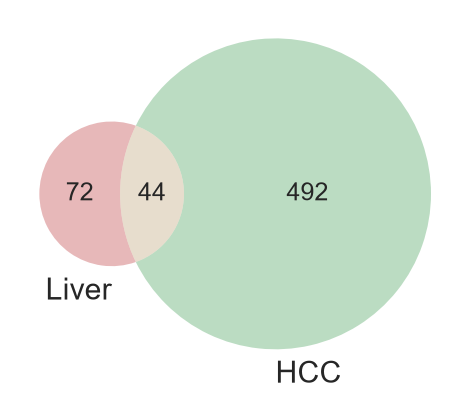

In [135]:
from matplotlib_venn import venn2

set1 = set(df_liver_sig.Gene)
set2 = set(df_hcc_sig.Gene)

venn2([set1, set2], ('Liver', 'HCC'))

plt.savefig(f'figures/Venn_sig_degs_liver_vs_hcc.pdf', dpi=300, bbox_inches='tight')

## 20. Imputation and limma revision audit

Quantify imputation among original hits and compare paired t-test results with the non-imputed limma sensitivity analysis.

In [136]:
def summarize_imputation_for_hits(
    raw_expression,
    sample_names,
    significant_features,
):
    """
    Summarize missing entries that required KNN imputation in the
    original analysis.

    raw_expression must be the matrix before KNN imputation.
    """

    sample_names = [
        str(sample) for sample in sample_names
        if str(sample) in raw_expression.columns.astype(str)
    ]

    raw = raw_expression.copy()
    raw.columns = raw.columns.astype(str)
    raw = raw.loc[:, sample_names]

    missing_mask = raw.isna()

    significant_features = pd.Index(
        significant_features
    ).drop_duplicates()

    significant_features = significant_features.intersection(
        raw.index
    )

    per_hit = pd.DataFrame(
        {
            "n_observed": raw.loc[
                significant_features
            ].notna().sum(axis=1),

            "n_imputed_in_original_analysis": raw.loc[
                significant_features
            ].isna().sum(axis=1),

            "imputed_fraction": raw.loc[
                significant_features
            ].isna().mean(axis=1),
        }
    )

    per_hit["contained_no_imputed_values"] = (
        per_hit["n_imputed_in_original_analysis"] == 0
    )

    hits_with_imputation = (
        per_hit["n_imputed_in_original_analysis"] > 0
    )

    median_imputed = (
        per_hit.loc[
            hits_with_imputation,
            "n_imputed_in_original_analysis",
        ].median()
        if hits_with_imputation.any()
        else 0
    )

    n_hits = per_hit.shape[0]
    n_zero_imputed = int(
        per_hit["contained_no_imputed_values"].sum()
    )

    summary = pd.Series(
        {
            "matrix_entries": raw.size,
            "matrix_missing_or_imputed_entries": int(
                missing_mask.sum().sum()
            ),
            "matrix_percent_imputed": (
                100 * missing_mask.sum().sum() / raw.size
            ),
            "significant_hits_found_in_matrix": n_hits,
            "significant_hits_with_zero_imputation": n_zero_imputed,
            "percent_significant_hits_with_zero_imputation": (
                100 * n_zero_imputed / n_hits
                if n_hits > 0
                else np.nan
            ),
            "significant_hits_with_imputation": int(
                hits_with_imputation.sum()
            ),
            "median_imputed_values_among_hits_with_imputation": (
                median_imputed
            ),
        },
        name="imputation_summary",
    )

    return summary, per_hit.sort_values(
        "n_imputed_in_original_analysis",
        ascending=False,
    )

In [137]:
old_liver_significant = df_liver_sig.index

old_hcc_significant = df_hcc_sig.index

In [138]:
liver_imputation_summary, liver_hit_missingness = (
    summarize_imputation_for_hits(
        raw_expression=df_liver,
        sample_names=liver_limma["paired_samples"],
        significant_features=old_liver_significant,
    )
)


hcc_imputation_summary, hcc_hit_missingness = (
    summarize_imputation_for_hits(
        raw_expression=df_hcc,
        sample_names=hcc_limma["paired_samples"],
        significant_features=old_hcc_significant,
    )
)

display(liver_imputation_summary.to_frame())
display(hcc_imputation_summary.to_frame())

,imputation_summary
matrix_entries,72666.000000
matrix_missing_or_imputed_entries,26994.000000
matrix_percent_imputed,37.148047
significant_hits_found_in_matrix,116.000000
significant_hits_with_zero_imputation,14.000000
percent_significant_hits_with_zero_imputation,12.068966
significant_hits_with_imputation,102.000000
median_imputed_values_among_hits_with_imputation,8.000000


,imputation_summary
matrix_entries,62226.000000
matrix_missing_or_imputed_entries,21008.000000
matrix_percent_imputed,33.760807
significant_hits_found_in_matrix,536.000000
significant_hits_with_zero_imputation,51.000000
percent_significant_hits_with_zero_imputation,9.514925
significant_hits_with_imputation,485.000000
median_imputed_values_among_hits_with_imputation,7.000000


In [139]:
liver_hit_audit = liver_hit_missingness.join(
    liver_limma['results'][
        [
            "log2FoldChange",
            "pvalue",
            "adj_pvalue",
            "n_complete_pairs",
        ]
    ],
    how="left",
)

hcc_hit_audit = hcc_hit_missingness.join(
    hcc_limma['results'][
        [
            "log2FoldChange",
            "pvalue",
            "adj_pvalue",
            "n_complete_pairs",
        ]
    ],
    how="left",
)

liver_hit_audit.to_csv(
    "liver_original_hits_imputation_and_limma_audit.csv"
)

hcc_hit_audit.to_csv(
    "hcc_original_hits_imputation_and_limma_audit.csv"
)

In [140]:
def compare_original_with_limma(
    original_results,
    limma_results,
    *,
    original_q_column,
    original_lfc_column,
    alpha=0.05,
):
    original = original_results[
        [original_q_column, original_lfc_column]
    ].copy()

    original = original.rename(
        columns={
            original_q_column: "original_qvalue",
            original_lfc_column: "original_log2FC",
        }
    )

    revised = limma_results[
        [
            "log2FoldChange",
            "adj_pvalue",
            "n_raw_missing_values",
            "n_complete_pairs",
        ]
    ].rename(
        columns={
            "log2FoldChange": "limma_log2FC",
            "adj_pvalue": "limma_qvalue",
        }
    )

    comparison = original.join(revised, how="left")

    original_significant = (
        comparison["original_qvalue"] < alpha
    )

    testable_by_limma = (
        original_significant
        & comparison["limma_qvalue"].notna()
    )

    replicated_by_limma = (
        testable_by_limma
        & (comparison["limma_qvalue"] < alpha)
    )

    same_direction = (
        testable_by_limma
        & (
            np.sign(comparison["original_log2FC"])
            == np.sign(comparison["limma_log2FC"])
        )
    )

    zero_missing = (
        testable_by_limma
        & (comparison["n_raw_missing_values"] == 0)
    )

    summary = pd.Series(
        {
            "original_significant_hits": int(
                original_significant.sum()
            ),
            "original_hits_testable_by_limma": int(
                testable_by_limma.sum()
            ),
            "original_hits_significant_by_limma": int(
                replicated_by_limma.sum()
            ),
            "percent_original_hits_significant_by_limma": (
                100
                * replicated_by_limma.sum()
                / testable_by_limma.sum()
                if testable_by_limma.sum() > 0
                else np.nan
            ),
            "original_hits_same_direction": int(
                same_direction.sum()
            ),
            "percent_original_hits_same_direction": (
                100
                * same_direction.sum()
                / testable_by_limma.sum()
                if testable_by_limma.sum() > 0
                else np.nan
            ),
            "original_hits_with_zero_missing_values": int(
                zero_missing.sum()
            ),
        },
        name="sensitivity_summary",
    )

    return summary, comparison

In [141]:
liver_ttest_results = pd.read_csv(f'phospho_ttest_liver_{today}.csv', index_col='ID')

hcc_ttest_results = pd.read_csv(f'phospho_ttest_hcc_{today}.csv', index_col='ID')

In [142]:
liver_sensitivity_summary, liver_method_comparison = (
    compare_original_with_limma(
        original_results=liver_ttest_results,
        limma_results=liver_limma['results'],
        original_q_column="ResectionvsBiopsy_adj_pval",          # change as needed
        original_lfc_column="ResectionvsBiopsy_fc", # change as needed
    )
)

hcc_sensitivity_summary, hcc_method_comparison = (
    compare_original_with_limma(
        original_results=hcc_ttest_results,
        limma_results=hcc_limma['results'],
        original_q_column="ResectionvsBiopsy_adj_pval",
        original_lfc_column="ResectionvsBiopsy_fc",
    )
)

display(liver_sensitivity_summary.to_frame())
display(hcc_sensitivity_summary.to_frame())

,sensitivity_summary
original_significant_hits,116.000000
original_hits_testable_by_limma,57.000000
original_hits_significant_by_limma,42.000000
percent_original_hits_significant_by_limma,73.684211
original_hits_same_direction,57.000000
percent_original_hits_same_direction,100.000000
original_hits_with_zero_missing_values,14.000000


,sensitivity_summary
original_significant_hits,536.000000
original_hits_testable_by_limma,240.000000
original_hits_significant_by_limma,113.000000
percent_original_hits_significant_by_limma,47.083333
original_hits_same_direction,240.000000
percent_original_hits_same_direction,100.000000
original_hits_with_zero_missing_values,51.000000
